In [9]:
# =============================================================================
# CELDA 1 CORREGIDA: CONFIGURACIÓN Y CARGA CON LAS 3 VARIABLES CLAVE
# =============================================================================

print("=" * 80)
print("ANÁLISIS PROFESIONAL - REGRESIÓN MULTIVARIABLE CON 3 VARIABLES CLAVE")
print("BASADO EN ANÁLISIS DE CORRELACIÓN PREVIO")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
import sys
from datetime import datetime
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy import stats
import joblib
from sklearn.utils import resample

# Configuración completa
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

class Config:
    DATA_PATH = r"C:\Users\PC\Desktop\ProjecteData\Equip_15\Data\RRHH_07102025_clean.parquet"
    OUTPUT_BASE = r"G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results"
    
    @property
    def OUTPUT_PATH(self):
        return os.path.join(self.OUTPUT_BASE, "Analisis_Absentisme _i_benestar_laboral_07102025")

config = Config()
os.makedirs(config.OUTPUT_PATH, exist_ok=True)

# DEFINIR LAS 3 VARIABLES SIGNIFICATIVAS
variables_especificas = [
    'Disciplinary_failure', 
    'Social_drinker', 
    'Social_smoker'
]

print(f"🎯 VARIABLES SELECCIONADAS BASADAS EN ANÁLISIS DE CORRELACIÓN:")
for i, var in enumerate(variables_especificas, 1):
    print(f"  {i}. {var}")

def clasificar_fuerza_mejorada(coef_estandarizado, p_value):
    """Clasificación mejorada de fuerza con significancia"""
    abs_coef = abs(coef_estandarizado)
    
    if p_value > 0.05:
        return "NO SIGNIFICATIVA", "⚪", 0
    
    if abs_coef >= 0.7:
        return "FUERTE", "🔴", 3
    elif abs_coef >= 0.3:
        return "MODERADA", "🟡", 2
    elif abs_coef >= 0.1:
        return "DÉBIL", "🟢", 1
    else:
        return "MUY DÉBIL", "⚪", 0

def convertir_tipos_datos_seguro(df):
    """
    Convierte las columnas a los tipos de datos correctos de forma segura
    CORRECCIÓN: Asegurar que todas las variables sean numéricas y manejar NaNs
    """
    print("🔄 CONVIRTIENDO TIPOS DE DATOS...")
    
    df_corregido = df.copy()
    
    # Lista de todas las variables que necesitamos (las 3 específicas y la variable objetivo)
    variables_a_convertir = variables_especificas + ['Absenteeism_hours']
    
    for columna in variables_a_convertir:
        if columna in df_corregido.columns:
            # Convertir a numérico, coercer errores (los no convertibles se convierten en NaN)
            df_corregido[columna] = pd.to_numeric(df_corregido[columna], errors='coerce')
            print(f"   ✓ {columna:25} convertida a numérico")
    
    # Eliminar filas con NaN en cualquiera de estas variables
    filas_antes = len(df_corregido)
    df_corregido = df_corregido.dropna(subset=variables_a_convertir)
    filas_despues = len(df_corregido)
    filas_eliminadas = filas_antes - filas_despues
    
    if filas_eliminadas > 0:
        print(f"   ⚠  Se eliminaron {filas_eliminadas} filas con valores NaN en las variables de interés")
    
    return df_corregido, filas_eliminadas

def analizar_calidad_datos(df):
    """Análisis completo de calidad de datos"""
    print(f"\n🔍 ANÁLISIS DE CALIDAD DE DATOS:")
    print(f"• Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(f"• Valores nulos totales: {df.isnull().sum().sum()}")
    print(f"• Duplicados exactos: {df.duplicated().sum()}")
    
    print(f"• LAS 3 VARIABLES CLAVE Y SUS CARACTERÍSTICAS:")
    
    for var in variables_especificas + ['Absenteeism_hours']:
        if var in df.columns:
            n_nulos = df[var].isnull().sum()
            n_unicos = df[var].nunique()
            tipo = df[var].dtype
            valores_unicos = df[var].unique()[:5]
            print(f"  - {var:25} | Nulos: {n_nulos:3} | Únicos: {n_unicos:3} | Tipo: {tipo} | Valores: {valores_unicos}")

# Cargar datos con manejo de errores
print("📊 CARGANDO DATOS...")
try:
    df = pd.read_parquet(config.DATA_PATH)
    print(f"✅ Dataset cargado exitosamente: {df.shape[0]} filas, {df.shape[1]} columnas")
    
    # Mostrar primeras filas para verificación
    print(f"\n📋 MUESTRA DE DATOS (primeras 3 filas):")
    print(df.head(3))
    
except Exception as e:
    print(f"❌ ERROR cargando datos: {e}")
    sys.exit(1)

# CONVERSIÓN DE TIPOS DE DATOS PRIMERO
print(f"\n🔄 CONVERSIÓN DE TIPOS DE DATOS...")
df, filas_eliminadas = convertir_tipos_datos_seguro(df)

# Análisis de calidad de datos después de la conversión
analizar_calidad_datos(df)

# Filtrar datos para análisis
print(f"\n🎯 PREPARANDO DATOS PARA ANÁLISIS...")
df_filtered = df.copy()
print(f"✅ Datos filtrados: {len(df_filtered)} registros totales (se eliminaron {filas_eliminadas} filas con NaNs)")

# Verificar que tenemos suficientes datos después del filtrado
if len(df_filtered) < 10:
    print("❌ ERROR: Muy pocos registros después del filtrado. Revisar los datos.")
    sys.exit(1)

# Verificar que todas las variables existen y son numéricas
variables_faltantes = [var for var in variables_especificas if var not in df_filtered.columns]
if variables_faltantes:
    print(f"❌ ERROR: Variables faltantes: {variables_faltantes}")
    sys.exit(1)

# Verificar tipos de datos
print(f"\n🔍 VERIFICANDO TIPOS DE DATOS FINALES:")
for var in variables_especificas + ['Absenteeism_hours']:
    if var in df_filtered.columns:
        tipo = df_filtered[var].dtype
        n_nulos = df_filtered[var].isnull().sum()
        valores_unicos = df_filtered[var].unique()[:5]
        print(f"  - {var:25} | Tipo: {str(tipo):10} | Nulos: {n_nulos} | Valores: {valores_unicos}")

print(f"✅ Todas las 3 variables necesarias están disponibles")

# Preparar datos para el modelo
X = df_filtered[variables_especificas].copy()
y = df_filtered['Absenteeism_hours'].copy()

# Calcular métricas clave
horas_promedio = y.mean()
horas_total = y.sum()
horas_std = y.std()

print(f"\n📊 MÉTRICAS CLAVE DEL ANÁLISIS:")
print(f"• Variable objetivo: Absenteeism_hours")
print(f"• Variables predictoras: {len(variables_especificas)}")
print(f"• Horas totales de ausentismo: {horas_total:.0f} horas")
print(f"• Horas promedio por empleado: {horas_promedio:.2f} horas")
print(f"• Desviación estándar: {horas_std:.2f} horas")
print(f"• Rango de ausentismo: [{y.min():.1f} - {y.max():.1f}] horas")

# Análisis de distribución del ausentismo
print(f"\n📈 DISTRIBUCIÓN DEL AUSENTISMO:")
print(f"• Mediana: {y.median():.2f} horas")
print(f"• Asimetría: {y.skew():.2f}")
print(f"• Curtosis: {y.kurtosis():.2f}")

# Análisis por percentiles
print(f"\n🎯 ANÁLISIS POR PERCENTILES:")
percentiles = [25, 50, 75, 90, 95, 99]
for p in percentiles:
    valor = np.percentile(y, p)
    print(f"• P{p:2}: {valor:6.2f} horas")

# ANÁLISIS ESPECÍFICO DE CADA VARIABLE
print(f"\n🔍 ANÁLISIS ESPECÍFICO POR VARIABLE:")

for var in variables_especificas:
    print(f"\n• {var}:")
    
    # Variables binarias - análisis específico
    for valor in sorted(X[var].unique()):
        if not pd.isna(valor):
            mascara = X[var] == valor
            count = mascara.sum()
            porcentaje = (count / len(X)) * 100
            ausentismo_promedio = y[mascara].mean() if count > 0 else 0
            ausentismo_std = y[mascara].std() if count > 0 else 0
            
            if var == 'Disciplinary_failure':
                etiqueta = "SIN fallo disciplinario" if valor == 0 else "CON fallo disciplinario"
            elif var == 'Social_drinker':
                etiqueta = "NO bebedor social" if valor == 0 else "Bebedor social"
            elif var == 'Social_smoker':
                etiqueta = "NO fumador social" if valor == 0 else "Fumador social"
            else:
                etiqueta = f"Valor {valor}"
                
            print(f"  - {etiqueta}: {count:3} personas ({porcentaje:5.1f}%) - {ausentismo_promedio:.2f} ± {ausentismo_std:.2f} horas")

# ANÁLISIS DE CORRELACIONES BIVARIADAS
print(f"\n📊 ANÁLISIS DE CORRELACIONES BIVARIADAS:")
for var in variables_especificas:
    correlacion_pearson = X[var].corr(y)
    correlacion_spearman = X[var].corr(y, method='spearman')
    print(f"• {var:25}: Pearson = {correlacion_pearson:.4f}, Spearman = {correlacion_spearman:.4f}")

# Guardar información del análisis inicial
print(f"\n💾 GUARDANDO INFORMACIÓN DEL ANÁLISIS INICIAL...")

# Crear resumen inicial
resumen_inicial = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'total_registros': len(df),
    'registros_filtrados': len(df_filtered),
    'horas_promedio_ausentismo': float(horas_promedio),
    'horas_total_ausentismo': float(horas_total),
    'variables_analizadas': variables_especificas,
    'filas_eliminadas_por_nan': filas_eliminadas
}

# Guardar resumen inicial
import json
with open(f'{config.OUTPUT_PATH}/resumen_inicial.json', 'w', encoding='utf-8') as f:
    json.dump(resumen_inicial, f, indent=2, ensure_ascii=False)

print(f"✅ CELDA 1 COMPLETADA EXITOSAMENTE")
print(f"📁 Resultados guardados en: {config.OUTPUT_PATH}")
print(f"📊 Datos preparados para análisis: {X.shape[0]} observaciones, {X.shape[1]} variables")
print(f"🎯 Variable objetivo: {y.shape[0]} valores, promedio: {horas_promedio:.2f} horas")

ANÁLISIS PROFESIONAL - REGRESIÓN MULTIVARIABLE CON 3 VARIABLES CLAVE
BASADO EN ANÁLISIS DE CORRELACIÓN PREVIO
🎯 VARIABLES SELECCIONADAS BASADAS EN ANÁLISIS DE CORRELACIÓN:
  1. Disciplinary_failure
  2. Social_drinker
  3. Social_smoker
📊 CARGANDO DATOS...
✅ Dataset cargado exitosamente: 1056 filas, 26 columnas

📋 MUESTRA DE DATOS (primeras 3 filas):
   ID                                     Reason_absence Month_absence  \
0  14                 Enfermedades del sistema digestivo     Noviembre   
1  36  Enfermedades del sistema musculoesquelético y ...         Abril   
2   9                  Enfermedades del sistema nervioso         Julio   

    Day_week    Seasons  Transportation_expense  Distance_Residence_Work  \
0      Lunes  Primavera                   155.0                     12.0   
1  Miercoles     Verano                   118.0                     13.0   
2     Martes   Invierno                   228.0                     14.0   

   Service_time   Age  Work_load_Average_day 

In [10]:
# =============================================================================
# CELDA 2 CORREGIDA: MODELADO CON LAS 3 VARIABLES SIGNIFICATIVAS
# =============================================================================

print("\n" + "=" * 80)
print("FASE 1: MODELADO MULTIVARIABLE CON 3 VARIABLES CLAVE")
print("=" * 80)

def aplicar_oversampling_disciplinary(df, y):
    """
    Aplicar oversampling para balancear Disciplinary_failure
    """
    print("\n🔄 APLICANDO OVERSAMPLING PARA BALANCEAR DATOS...")
    
    # Verificar distribución original
    original_counts = df['Disciplinary_failure'].value_counts()
    print(f"• Distribución original: {dict(original_counts)}")
    
    # Separar mayoría y minoría
    df_majority = df[df['Disciplinary_failure'] == 0]
    df_minority = df[df['Disciplinary_failure'] == 1]
    
    if len(df_minority) == 0:
        print("⚠ No hay casos con Disciplinary_failure = 1")
        return df, y
    
    # Oversample minority class
    df_minority_upsampled = resample(df_minority,
                                    replace=True,
                                    n_samples=len(df_majority)//3,
                                    random_state=42)
    
    # Combinar con mayoría
    df_balanced = pd.concat([df_majority, df_minority_upsampled])
    y_balanced = pd.concat([
        y[df_majority.index],
        y[df_minority_upsampled.index]
    ])
    
    # Verificar nueva distribución
    balanced_counts = df_balanced['Disciplinary_failure'].value_counts()
    print(f"• Distribución balanceada: {dict(balanced_counts)}")
    print(f"• Tamaño dataset original: {len(df)}")
    print(f"• Tamaño dataset balanceado: {len(df_balanced)}")
    
    return df_balanced, y_balanced

def modelo_con_robustez(df, y, variables_especificas):
    """
    Versión mejorada del modelado con técnicas robustas
    """
    print("\n🎯 MODELADO ROBUSTO CON TÉCNICAS AVANZADAS")
    
    resultados_modelos = {}
    
    # 1. MODELO ORIGINAL (sin modificaciones)
    print("\n1. 📊 MODELO ORIGINAL:")
    X_original = df[variables_especificas]
    X_const_original = sm.add_constant(X_original)
    modelo_original = sm.OLS(y, X_const_original).fit()
    resultados_modelos['original'] = modelo_original
    
    # 2. MODELO CON PESOS PARA DESBALANCEO
    print("\n2. ⚖️ MODELO CON PESOS:")
    try:
        # Calcular pesos inversamente proporcionales a la frecuencia de clase
        disciplinary_counts = df['Disciplinary_failure'].value_counts()
        if len(disciplinary_counts) > 1:
            weight_1 = len(df) / (2 * disciplinary_counts[1])
            weight_0 = len(df) / (2 * disciplinary_counts[0])
            sample_weights = np.where(df['Disciplinary_failure'] == 1, weight_1, weight_0)
            
            modelo_pesos = sm.OLS(y, X_const_original, weights=sample_weights).fit()
            resultados_modelos['con_pesos'] = modelo_pesos
            print(f"   • Pesos aplicados: 0->{weight_0:.2f}, 1->{weight_1:.2f}")
        else:
            print("   • No se pudieron calcular pesos (solo una clase)")
    except Exception as e:
        print(f"   • Error en modelo con pesos: {e}")
    
    # 3. MODELO CON OVERSAMPLING
    print("\n3. 🔄 MODELO CON OVERSAMPLING:")
    try:
        df_balanced, y_balanced = aplicar_oversampling_disciplinary(df, y)
        if len(df_balanced) > len(df) * 0.3:
            X_balanced = df_balanced[variables_especificas]
            X_const_balanced = sm.add_constant(X_balanced)
            modelo_balanced = sm.OLS(y_balanced, X_const_balanced).fit()
            resultados_modelos['con_oversampling'] = modelo_balanced
        else:
            print("   • Oversampling no produjo suficiente datos")
    except Exception as e:
        print(f"   • Error en modelo con oversampling: {e}")
    
    # 4. MODELO CON ALGORITMO ROBUSTO (Random Forest)
    print("\n4. 🌲 MODELO CON RANDOM FOREST:")
    try:
        rf_model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=10,
            random_state=42
        )
        
        # Validación cruzada
        cv_scores_rf = cross_val_score(rf_model, X_original, y, cv=5, scoring='r2')
        print(f"   • R² CV (Random Forest): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
        
        # Entrenar modelo completo
        rf_model.fit(X_original, y)
        resultados_modelos['random_forest'] = rf_model
        
    except Exception as e:
        print(f"   • Error en Random Forest: {e}")
    
    return resultados_modelos

# EJECUTAR MODELOS ROBUSTOS
resultados_modelos = modelo_con_robustez(X[variables_especificas], y, variables_especificas)

# COMPARAR COEFICIENTES ENTRE MODELOS
print("\n" + "="*80)
print("📊 COMPARACIÓN DE COEFICIENTES ENTRE MODELOS")
print("="*80)

for nombre, modelo in resultados_modelos.items():
    if hasattr(modelo, 'params'):
        print(f"\n• {nombre.upper()}:")
        for var in variables_especificas:
            if var in modelo.params:
                coef = modelo.params[var]
                p_val = modelo.pvalues.get(var, 1)
                significativo = "✅" if p_val < 0.05 else "⚠️"
                print(f"  {var:25}: {coef:10.6f} (p={p_val:.4f}) {significativo}")
    elif hasattr(modelo, 'feature_importances_'):
        print(f"\n• {nombre.upper()} (Importancia):")
        for i, var in enumerate(variables_especificas):
            if var in X.columns:
                importancia = modelo.feature_importances_[i]
                print(f"  {var:25}: {importancia:.6f}")

# ANÁLISIS DE ESTABILIDAD CON BOOTSTRAP
print("\n📈 ANÁLISIS DE ESTABILIDAD CON BOOTSTRAP:")

def analisis_bootstrap_variables(X_data, y_data, variables, n_bootstrap=500):
    """Análisis de estabilidad con bootstrapping para todas las variables"""
    bootstrap_coefs = {var: [] for var in variables}
    
    for _ in range(n_bootstrap):
        try:
            # Muestra bootstrap
            indices = np.random.choice(len(X_data), len(X_data), replace=True)
            X_boot = X_data.iloc[indices]
            y_boot = y_data.iloc[indices]
            
            # Modelo en muestra bootstrap
            X_const_boot = sm.add_constant(X_boot)
            model_boot = sm.OLS(y_boot, X_const_boot).fit()
            
            for var in variables:
                if var in model_boot.params:
                    bootstrap_coefs[var].append(model_boot.params[var])
        except:
            continue
    
    # Calcular estadísticas de bootstrap
    print("• Estabilidad de coeficientes (bootstrap):")
    for var in variables:
        if bootstrap_coefs[var]:
            coef_original = resultados_modelos['original'].params.get(var, 0)
            coef_bootstrap_mean = np.mean(bootstrap_coefs[var])
            coef_bootstrap_std = np.std(bootstrap_coefs[var])
            diferencia_relativa = abs(coef_original - coef_bootstrap_mean) / abs(coef_original) if coef_original != 0 else 0
            
            estabilidad = "ALTA" if diferencia_relativa < 0.1 else "MEDIA" if diferencia_relativa < 0.3 else "BAJA"
            print(f"  - {var:25}: {coef_original:8.4f} ± {coef_bootstrap_std:.4f} ({estabilidad})")

analisis_bootstrap_variables(X[variables_especificas], y, variables_especificas)

# CONTINUAR CON EL ANÁLISIS ORIGINAL PERO MEJORADO
print("\n" + "="*80)
print("CONTINUACIÓN: ANÁLISIS MULTIVARIABLE ESTÁNDAR")
print("="*80)

# Estandarización mejorada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[variables_especificas])
X_scaled_df = pd.DataFrame(X_scaled, columns=variables_especificas, index=X.index)

# DIVISIÓN TRAIN-TEST PARA VALIDACIÓN
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, 4)
)

print(f"📊 DIVISIÓN DE DATOS:")
print(f"• Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"• Conjunto de prueba: {X_test.shape[0]} muestras")

# MODELO PRINCIPAL CON STATSMODELS
X_train_const = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_const)
results_sm = model_sm.fit()

# VALIDACIÓN CRUZADA MEJORADA
print(f"🔍 VALIDACIÓN CRUZADA ROBUSTA (5-fold):")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_scaled_df, y, cv=kf, scoring='r2')
cv_rmse = cross_val_score(LinearRegression(), X_scaled_df, y, cv=kf, scoring='neg_mean_squared_error')

print(f"• R² CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• RMSE CV: {np.sqrt(-cv_rmse.mean()):.4f}")

# MODELOS ALTERNATIVOS PARA COMPARACIÓN
print(f"🔍 COMPARACIÓN DE MODELOS:")
models = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"• {name:6}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

# MODELO FOREST PARA ANÁLISIS DE IMPORTANCIA
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importancia = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

print(f"🎯 IMPORTANCIA DE VARIABLES (Permutation Importance):")
for i, var in enumerate(variables_especificas):
    print(f"• {var:25}: {importancia.importances_mean[i]:.4f} ± {importancia.importances_std[i]:.4f}")

# Coeficientes del modelo principal
coef_estandarizados = results_sm.params.drop('const')
p_values = results_sm.pvalues.drop('const')

# Modelo sin estandarizar para coeficientes originales
X_original_const = sm.add_constant(X[variables_especificas])
model_original = sm.OLS(y, X_original_const)
results_original = model_original.fit()
coef_originales = results_original.params.drop('const')

# DataFrame de resultados mejorado
results_df = pd.DataFrame({
    'Variable': variables_especificas,
    'Coef_Estandarizado': coef_estandarizados,
    'Coef_No_Estandarizado': coef_originales,
    'P_value': p_values,
    'Significativa': p_values < 0.05,
    'Abs_Coef_Estand': abs(coef_estandarizados),
    'Importancia_Permutation': importancia.importances_mean
})

# Ordenar por importancia de permutación
results_df = results_df.sort_values('Importancia_Permutation', ascending=False)

# Diagnóstico de multicolinealidad mejorado
print(f"🔍 DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF):")
vif_data = pd.DataFrame()
vif_data["Variable"] = X_original_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_original_const.values, i) 
                   for i in range(X_original_const.shape[1])]
vif_data = vif_data[vif_data['Variable'] != 'const']

for _, row in vif_data.iterrows():
    status = "✅" if row['VIF'] < 5 else "⚠" if row['VIF'] < 10 else "🔴"
    interpretacion = "Sin multicolinealidad" if row['VIF'] < 5 else "Multicolinealidad moderada" if row['VIF'] < 10 else "Multicolinealidad alta"
    print(f"   {status} {row['Variable']:25} VIF = {row['VIF']:.2f} - {interpretacion}")

# ANÁLISIS DE RESIDUALES - CORREGIDO
print(f"📊 ANÁLISIS DE RESIDUALES DEL MODELO:")
residuals = results_sm.resid
print(f"• Media de residuales: {residuals.mean():.6f}")

# CORRECCIÓN: Usar scipy.stats.shapiro directamente en lugar de residuals.shapiro
from scipy.stats import shapiro
# Para datasets grandes (>5000), shapiro puede ser lento, así que tomamos una muestra si es necesario
if len(residuals) > 5000:
    residuals_sample = residuals.sample(5000, random_state=42)
else:
    residuals_sample = residuals

shapiro_test = shapiro(residuals_sample)
print(f"• Normalidad (Shapiro-Wilk): p-value = {shapiro_test[1]:.4f}")

# CORRECCIÓN: Usar het_breuschpagan correctamente
from statsmodels.stats.diagnostic import het_breuschpagan
# Convertir a arrays numpy para evitar problemas
residuals_np = residuals.values
X_train_const_np = X_train_const.values

bp_test = het_breuschpagan(residuals_np, X_train_const_np)
print(f"• Homocedasticidad (Breusch-Pagan): p-value = {bp_test[1]:.4f}")

# EVALUACIÓN FINAL DEL MODELO
print(f"🎯 EVALUACIÓN FINAL DEL MODELO:")
y_pred_train = results_sm.predict(X_train_const)
y_pred_test = results_sm.predict(sm.add_constant(X_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"• R² Entrenamiento: {r2_train:.4f}")
print(f"• R² Prueba: {r2_test:.4f}")
print(f"• RMSE Entrenamiento: {rmse_train:.4f}")
print(f"• RMSE Prueba: {rmse_test:.4f}")
print(f"• Diferencia R² (train-test): {r2_train - r2_test:.4f}")

# ANÁLISIS ESPECÍFICO DE CADA VARIABLE EN EL CONTEXTO MULTIVARIADO
print(f"🔍 ANÁLISIS ESPECÍFICO POR VARIABLE EN MODELO MULTIVARIADO:")

for var in variables_especificas:
    coef_std = results_df[results_df['Variable'] == var]['Coef_Estandarizado'].iloc[0]
    coef_orig = results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0]
    p_val = results_df[results_df['Variable'] == var]['P_value'].iloc[0]
    
    print(f"\n• {var}:")
    print(f"  - Coeficiente estandarizado: {coef_std:.4f}")
    print(f"  - Coeficiente original: {coef_orig:.6f}")
    print(f"  - p-value: {p_val:.4f}")
    print(f"  - Significativo: {'SÍ' if p_val < 0.05 else 'NO'}")
    print(f"  - Dirección: {'POSITIVA' if coef_orig > 0 else 'NEGATIVA'}")
    
    # Interpretación específica por variable
    if var in ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']:
        print(f"  - Interpretación: Tener {var} {'AUMENTA' if coef_orig > 0 else 'DISMINUYE'} el ausentismo en {abs(coef_orig):.4f} horas")

# Guardar el modelo principal para usar en celdas posteriores
modelo_principal = results_sm


FASE 1: MODELADO MULTIVARIABLE CON 3 VARIABLES CLAVE

🎯 MODELADO ROBUSTO CON TÉCNICAS AVANZADAS

1. 📊 MODELO ORIGINAL:

2. ⚖️ MODELO CON PESOS:
   • Pesos aplicados: 0->0.52, 1->10.78

3. 🔄 MODELO CON OVERSAMPLING:

🔄 APLICANDO OVERSAMPLING PARA BALANCEAR DATOS...
• Distribución original: {0: np.int64(1007), 1: np.int64(49)}
• Distribución balanceada: {0: np.int64(1007), 1: np.int64(335)}
• Tamaño dataset original: 1056
• Tamaño dataset balanceado: 1342

4. 🌲 MODELO CON RANDOM FOREST:
   • R² CV (Random Forest): -37.7079 ± 72.8104

📊 COMPARACIÓN DE COEFICIENTES ENTRE MODELOS

• ORIGINAL:
  Disciplinary_failure     :  -8.510309 (p=0.0001) ✅
  Social_drinker           :   2.738004 (p=0.0031) ✅
  Social_smoker            :   1.919901 (p=0.2669) ⚠️

• CON_PESOS:
  Disciplinary_failure     :  -8.510309 (p=0.0001) ✅
  Social_drinker           :   2.738004 (p=0.0031) ✅
  Social_smoker            :   1.919901 (p=0.2669) ⚠️

• CON_OVERSAMPLING:
  Disciplinary_failure     :  -8.428129 (p=0.0000

In [11]:
# =============================================================================
# CELDA 3 COMPLETA Y CORREGIDA: ANÁLISIS DE IMPACTO CON LAS 3 VARIABLES
# =============================================================================

print("\n" + "=" * 80)
print("FASE 2: ANÁLISIS DE IMPACTO CON LAS 3 VARIABLES CLAVE")
print("=" * 80)

# CALCULAR HORAS_PROMEDIO
horas_promedio = y.mean()
print(f"📊 Horas promedio de ausentismo calculadas: {horas_promedio:.2f}")

def guardar_grafico_seguro(plt, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar gráficos con manejo de errores"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        return False

def calcular_intervalos_confianza_bootstrap(X_data, y_data, variables, n_bootstrap=500):
    """Calcula intervalos de confianza usando bootstrapping"""
    coef_bootstrap = {var: [] for var in variables}
    
    for _ in range(n_bootstrap):
        # Muestra bootstrap
        indices = np.random.choice(len(X_data), len(X_data), replace=True)
        X_boot = X_data.iloc[indices]
        y_boot = y_data.iloc[indices]
        
        # Modelo en muestra bootstrap
        X_const = sm.add_constant(X_boot)
        try:
            model = sm.OLS(y_boot, X_const).fit()
            
            for var in variables:
                if var in model.params:
                    coef_bootstrap[var].append(model.params[var])
        except:
            continue
    
    # Calcular intervalos de confianza (95%)
    intervals = {}
    for var in variables:
        if coef_bootstrap[var]:
            alpha = 0.05
            lower = np.percentile(coef_bootstrap[var], (alpha/2)*100)
            upper = np.percentile(coef_bootstrap[var], (1-alpha/2)*100)
            intervals[var] = (lower, upper)
        else:
            intervals[var] = (np.nan, np.nan)
    
    return intervals

# Calcular intervalos de confianza
print("🔍 CALCULANDO INTERVALOS DE CONFIANZA CON BOOTSTRAPPING...")
confidence_intervals = calcular_intervalos_confianza_bootstrap(
    X[variables_especificas], y, variables_especificas, n_bootstrap=500
)

# Añadir intervalos al DataFrame de resultados
results_df['CI_Lower'] = results_df['Variable'].apply(
    lambda var: confidence_intervals.get(var, (np.nan, np.nan))[0] if var in confidence_intervals else np.nan
)
results_df['CI_Upper'] = results_df['Variable'].apply(
    lambda var: confidence_intervals.get(var, (np.nan, np.nan))[1] if var in confidence_intervals else np.nan
)

def calcular_impacto_practico_avanzado(coef_no_estandarizado, variable, X_data, y_data, horas_promedio, ci_lower=None, ci_upper=None):
    """Calcular impacto práctico con intervalos de confianza"""
    
    # VERIFICACIÓN ESPECIAL PARA VARIABLES BINARIAS
    if variable in ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']:
        # Para binarias, calcular diferencia real entre grupos
        if variable in X_data.columns:
            grupo_0 = y_data[X_data[variable] == 0]
            grupo_1 = y_data[X_data[variable] == 1]
            
            if len(grupo_0) > 0 and len(grupo_1) > 0:
                impacto_real = grupo_1.mean() - grupo_0.mean()
                
                # Usar el impacto real si es significativamente diferente del coeficiente
                if abs(impacto_real - coef_no_estandarizado) > 0.5:
                    coef_no_estandarizado = impacto_real
                    print(f"   🔄 Usando diferencia real para {variable}: {impacto_real:.4f}")
    
    # Todas nuestras variables son binarias
    if variable in ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']:
        # Variables binarias
        impacto_horas = coef_no_estandarizado
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        
        if variable == 'Disciplinary_failure':
            interpretacion = "Con fallo disciplinario vs Sin fallo"
        elif variable == 'Social_drinker':
            interpretacion = "Bebedor social vs No bebedor"
        else:  # Social_smoker
            interpretacion = "Fumador social vs No fumador"
            
    # Calcular intervalos de confianza para el impacto
    if ci_lower is not None and ci_upper is not None and not np.isnan(ci_lower) and not np.isnan(ci_upper):
        impacto_ci_lower = ci_lower
        impacto_ci_upper = ci_upper
    else:
        impacto_ci_lower = impacto_ci_upper = None
    
    return {
        'impacto_horas': impacto_horas,
        'impacto_porcentaje': impacto_porcentaje,
        'interpretacion': interpretacion,
        'ci_lower': impacto_ci_lower,
        'ci_upper': impacto_ci_upper
    }

# Aplicar análisis mejorado a cada variable
print("📊 MAGNITUD ESTANDARIZADA CON SIGNIFICANCIA:")
print("-" * 60)

for _, row in results_df.iterrows():
    fuerza, emoji, peso = clasificar_fuerza_mejorada(row['Coef_Estandarizado'], row['P_value'])
    direccion = "POSITIVA" if row['Coef_Estandarizado'] > 0 else "NEGATIVA"
    signo = "✓" if row['Significativa'] else "✗"
    
    nombre_formateado = f"{row['Variable']:25}"
    print(f"{emoji} {signo} {nombre_formateado} {row['Coef_Estandarizado']:7.4f} {direccion:8} [{fuerza}]")

print(f"\n📏 MAGNITUD DE EFECTOS CON INTERVALOS DE CONFIANZA:")
print("-" * 60)

impactos_detallados = {}
for _, row in results_df.iterrows():
    resultado = calcular_impacto_practico_avanzado(
        row['Coef_No_Estandarizado'], 
        row['Variable'], 
        X, 
        y,
        horas_promedio,
        row.get('CI_Lower', None),
        row.get('CI_Upper', None)
    )
    
    impactos_detallados[row['Variable']] = resultado
    
    direccion = "AUMENTA" if row['Coef_No_Estandarizado'] > 0 else "DISMINUYE"
    nombre_formateado = f"{row['Variable']:25}"
    
    # Mostrar impacto con intervalo de confianza
    if resultado['ci_lower'] is not None and not np.isnan(resultado['ci_lower']):
        print(f"• {nombre_formateado} {row['Coef_No_Estandarizado']:7.4f}")
        print(f"  → Impacto: {abs(resultado['impacto_horas']):.2f} horas ({resultado['impacto_porcentaje']:+.1f}%)")
        print(f"  → IC 95%: [{resultado['ci_lower']:.2f}, {resultado['ci_upper']:.2f}]")
        print(f"  → {resultado['interpretacion']} {direccion} el ausentismo")
    else:
        print(f"• {nombre_formateado} {row['Coef_No_Estandarizado']:7.4f}")
        print(f"  → Impacto: {abs(resultado['impacto_horas']):.2f} horas ({resultado['impacto_porcentaje']:+.1f}%)")
        print(f"  → {resultado['interpretacion']} {direccion} el ausentismo")
    print()

# Verificar que tenemos todos los impactos calculados
print(f"✅ Impactos calculados para {len(impactos_detallados)} variables")

# =============================================================================
# GRÁFICO: COEFICIENTES CON INTERVALOS DE CONFIANZA
# =============================================================================
print("\n📈 CREANDO GRÁFICO 1: COEFICIENTES CON INTERVALOS DE CONFIANZA...")

plt.figure(figsize=(14, 8))

# Preparar datos
plot_data = results_df.copy()
plot_data = plot_data.sort_values('Coef_Estandarizado', ascending=True)

# Crear gráfico de coeficientes con intervalos
y_pos = np.arange(len(plot_data))
colors = ['#E74C3C' if coef > 0 else '#3498DB' for coef in plot_data['Coef_Estandarizado']]

# Barras principales
bars = plt.barh(y_pos, plot_data['Coef_Estandarizado'], 
                color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Añadir intervalos de confianza
for i, (coef, ci_low, ci_high, p_val) in enumerate(zip(
    plot_data['Coef_Estandarizado'],
    plot_data['CI_Lower'],
    plot_data['CI_Upper'], 
    plot_data['P_value']
)):
    # Línea de intervalo
    plt.plot([ci_low, ci_high], [i, i], color='black', linewidth=2)
    # Marcadores en los extremos
    plt.plot(ci_low, i, '|', color='black', markersize=10)
    plt.plot(ci_high, i, '|', color='black', markersize=10)
    
    # Texto del coeficiente
    if p_val < 0.05:
        texto = f'{coef:.3f}*'
        color_texto = 'darkred' if coef > 0 else 'darkblue'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="gold", alpha=0.8)
    else:
        texto = f'{coef:.3f}'
        color_texto = 'black'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    plt.text(coef + (0.02 if coef > 0 else -0.02), i, texto,
             va='center', ha='left' if coef > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10,
             bbox=bbox_style)

plt.yticks(y_pos, plot_data['Variable'])
plt.xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

plt.title('COEFICIENTES ESTANDARIZADOS CON INTERVALOS DE CONFIANZA 95%\\n' +
          'LAS 3 VARIABLES BINARIAS: FALLO DISCIPLINARIO, BEBEDOR SOCIAL Y FUMADOR SOCIAL', 
          fontsize=14, fontweight='bold', pad=20)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.7, label='Aumenta Ausentismo'),
    Patch(facecolor='#3498DB', alpha=0.7, label='Disminuye Ausentismo'),
    plt.Line2D([0], [0], color='black', linewidth=2, label='IC 95%'),
    plt.Line2D([0], [0], marker='|', color='black', markersize=10, label='Límites IC')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
guardar_grafico_seguro(plt, '1_coeficientes_con_intervalos_3_variables.png')
plt.close()
print("✓ Gráfico de coeficientes con intervalos guardado")

# =============================================================================
# GRÁFICO: IMPACTO PRÁCTICO EN HORAS
# =============================================================================
print("\n📊 CREANDO GRÁFICO 2: IMPACTO PRÁCTICO EN HORAS...")

plt.figure(figsize=(14, 8))

# Preparar datos de impacto
impacto_data = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        impacto_data.append({
            'Variable': var,
            'Impacto_Horas': impacto_info['impacto_horas'],
            'Impacto_Porcentaje': impacto_info['impacto_porcentaje'],
            'Significativa': row['Significativa'],
            'Direccion': 'AUMENTA' if impacto_info['impacto_horas'] > 0 else 'DISMINUYE'
        })

impacto_df = pd.DataFrame(impacto_data)
impacto_df = impacto_df.sort_values('Impacto_Horas', ascending=True)

# Crear gráfico
y_pos = np.arange(len(impacto_df))
colors = ['#E74C3C' if impacto > 0 else '#3498DB' for impacto in impacto_df['Impacto_Horas']]

bars = plt.barh(y_pos, impacto_df['Impacto_Horas'], color=colors, alpha=0.7, edgecolor='black')

# Añadir valores y detalles
for i, (impacto, porcentaje, sig, var) in enumerate(zip(
    impacto_df['Impacto_Horas'],
    impacto_df['Impacto_Porcentaje'],
    impacto_df['Significativa'],
    impacto_df['Variable']
)):
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    signo = '+' if impacto > 0 else ''
    
    if sig:
        texto = f'{signo}{impacto:.2f}h*'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="gold", alpha=0.8)
    else:
        texto = f'{signo}{impacto:.2f}h'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    plt.text(impacto + (0.1 if impacto > 0 else -0.1), i, texto,
             va='center', ha='left' if impacto > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10,
             bbox=bbox_style)

plt.yticks(y_pos, impacto_df['Variable'])
plt.xlabel('Impacto Práctico (horas)', fontweight='bold', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

plt.title('IMPACTO PRÁCTICO EN HORAS DE AUSENTISMO LABORAL\\n' +
          'LAS 3 VARIABLES BINARIAS ANALIZADAS (* = Significativo p < 0.05)', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
guardar_grafico_seguro(plt, '2_impacto_practico_3_variables.png')
plt.close()
print("✓ Gráfico de impacto práctico en horas guardado")

# =============================================================================
# GRÁFICO ADICIONAL: COMPARACIÓN DE GRUPOS POR VARIABLE BINARIA
# =============================================================================
print("\n📈 CREANDO GRÁFICO 3: COMPARACIÓN DE GRUPOS POR VARIABLE BINARIA...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('COMPARACIÓN DE HORAS DE AUSENTISMO POR GRUPOS - VARIABLES BINARIAS', 
             fontsize=16, fontweight='bold', y=0.95)

# Diccionario de etiquetas para las variables
etiquetas_variables = {
    'Disciplinary_failure': {
        0: 'Sin Fallo\\nDisciplinario',
        1: 'Con Fallo\\nDisciplinario'
    },
    'Social_drinker': {
        0: 'No Bebedor\\nSocial', 
        1: 'Bebedor\\nSocial'
    },
    'Social_smoker': {
        0: 'No Fumador\\nSocial',
        1: 'Fumador\\nSocial'
    }
}

colores = ['#3498DB', '#E74C3C']  # Azul para grupo 0, Rojo para grupo 1

for idx, var in enumerate(variables_especificas):
    ax = axes[idx]
    
    # Preparar datos para esta variable
    datos_grupo_0 = y[X[var] == 0]
    datos_grupo_1 = y[X[var] == 1]
    
    # Estadísticas descriptivas
    media_0 = datos_grupo_0.mean()
    media_1 = datos_grupo_1.mean()
    std_0 = datos_grupo_0.std()
    std_1 = datos_grupo_1.std()
    
    # Crear boxplot
    box_data = [datos_grupo_0, datos_grupo_1]
    box_plot = ax.boxplot(box_data, labels=[etiquetas_variables[var][0], etiquetas_variables[var][1]], 
                         patch_artist=True, widths=0.6)
    
    # Colorear las cajas
    for patch, color in zip(box_plot['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Añadir líneas de media
    ax.axhline(y=media_0, color='blue', linestyle='--', alpha=0.7, linewidth=1)
    ax.axhline(y=media_1, color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Añadir valores de media
    ax.text(0.5, media_0 + 0.5, f'Media: {media_0:.1f}h', 
            ha='center', va='bottom', fontweight='bold', color='blue')
    ax.text(1.5, media_1 + 0.5, f'Media: {media_1:.1f}h', 
            ha='center', va='bottom', fontweight='bold', color='red')
    
    # Calcular diferencia y test de significancia
    from scipy.stats import ttest_ind
    t_stat, p_valor = ttest_ind(datos_grupo_0, datos_grupo_1, equal_var=False)
    diferencia = media_1 - media_0
    
    # Añadir información de significancia
    if p_valor < 0.05:
        ax.text(1, ax.get_ylim()[1] * 0.95, f'Diferencia: {diferencia:+.1f}h\\n(p = {p_valor:.4f})*', 
                ha='center', va='top', fontweight='bold', color='green',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))
    else:
        ax.text(1, ax.get_ylim()[1] * 0.95, f'Diferencia: {diferencia:+.1f}h\\n(p = {p_valor:.4f})', 
                ha='center', va='top', fontweight='bold', color='gray',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    
    ax.set_ylabel('Horas de Ausentismo', fontweight='bold')
    ax.set_title(f'{var}\\nComparación entre Grupos', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
guardar_grafico_seguro(plt, '3_comparacion_grupos_binarios.png')
plt.close()
print("✓ Gráfico de comparación de grupos guardado")

# =============================================================================
# ANÁLISIS DETALLADO DE CADA VARIABLE BINARIA
# =============================================================================
print(f"\n🔍 ANÁLISIS DETALLADO POR VARIABLE BINARIA:")
print("-" * 60)

for var in variables_especificas:
    print(f"\n📊 ANÁLISIS DETALLADO - {var}:")
    
    # Estadísticas por grupo
    grupo_0 = y[X[var] == 0]
    grupo_1 = y[X[var] == 1]
    
    n_0 = len(grupo_0)
    n_1 = len(grupo_1)
    porcentaje_0 = (n_0 / len(X)) * 100
    porcentaje_1 = (n_1 / len(X)) * 100
    
    media_0 = grupo_0.mean()
    media_1 = grupo_1.mean()
    std_0 = grupo_0.std()
    std_1 = grupo_1.std()
    
    diferencia = media_1 - media_0
    diferencia_porcentaje = (diferencia / horas_promedio) * 100
    
    # Test de significancia
    from scipy.stats import ttest_ind
    t_stat, p_valor = ttest_ind(grupo_0, grupo_1, equal_var=False)
    
    print(f"  • Distribución:")
    if var == 'Disciplinary_failure':
        print(f"    - Sin fallo disciplinario: {n_0:3} personas ({porcentaje_0:5.1f}%) - {media_0:.2f} ± {std_0:.2f} horas")
        print(f"    - Con fallo disciplinario: {n_1:3} personas ({porcentaje_1:5.1f}%) - {media_1:.2f} ± {std_1:.2f} horas")
    elif var == 'Social_drinker':
        print(f"    - No bebedor social: {n_0:3} personas ({porcentaje_0:5.1f}%) - {media_0:.2f} ± {std_0:.2f} horas")
        print(f"    - Bebedor social: {n_1:3} personas ({porcentaje_1:5.1f}%) - {media_1:.2f} ± {std_1:.2f} horas")
    else:  # Social_smoker
        print(f"    - No fumador social: {n_0:3} personas ({porcentaje_0:5.1f}%) - {media_0:.2f} ± {std_0:.2f} horas")
        print(f"    - Fumador social: {n_1:3} personas ({porcentaje_1:5.1f}%) - {media_1:.2f} ± {std_1:.2f} horas")
    
    print(f"  • Diferencia entre grupos: {diferencia:+.2f} horas ({diferencia_porcentaje:+.1f}%)")
    print(f"  • Significancia estadística (t-test): p = {p_valor:.4f}")
    print(f"  • Interpretación: El grupo {var} {'AUMENTA' if diferencia > 0 else 'DISMINUYE'} el ausentismo en {abs(diferencia):.2f} horas")

# =============================================================================
# RESUMEN EJECUTIVO DEL IMPACTO
# =============================================================================
print(f"\n🎯 RESUMEN EJECUTIVO DEL IMPACTO:")
print("-" * 60)

# Calcular impacto total
impacto_total_positivo = 0
impacto_total_negativo = 0
variables_significativas = []

for var in variables_especificas:
    if var in impactos_detallados:
        impacto = impactos_detallados[var]['impacto_horas']
        if impacto > 0:
            impacto_total_positivo += abs(impacto)
        else:
            impacto_total_negativo += abs(impacto)
        
        row = results_df[results_df['Variable'] == var].iloc[0]
        if row['Significativa']:
            variables_significativas.append(var)

print(f"• Impacto total que AUMENTA ausentismo: {impacto_total_positivo:.2f} horas")
print(f"• Impacto total que DISMINUYE ausentismo: {impacto_total_negativo:.2f} horas")
print(f"• Impacto neto potencial: {impacto_total_positivo - impacto_total_negativo:+.2f} horas")
print(f"• Variables significativas: {len(variables_significativas)}/{len(variables_especificas)}")
if variables_significativas:
    print(f"  - {', '.join(variables_significativas)}")

# =============================================================================
# GUARDAR DATOS DE IMPACTO PARA USO POSTERIOR
# =============================================================================
print(f"\n💾 GUARDANDO DATOS DE IMPACTO DETALLADOS...")

# Crear DataFrame con todos los impactos
impacto_completo_df = pd.DataFrame({
    'Variable': variables_especificas,
    'Coeficiente_Original': [results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0] for var in variables_especificas],
    'Coeficiente_Estandarizado': [results_df[results_df['Variable'] == var]['Coef_Estandarizado'].iloc[0] for var in variables_especificas],
    'P_value': [results_df[results_df['Variable'] == var]['P_value'].iloc[0] for var in variables_especificas],
    'Significativa': [results_df[results_df['Variable'] == var]['Significativa'].iloc[0] for var in variables_especificas],
    'Impacto_Horas': [impactos_detallados[var]['impacto_horas'] for var in variables_especificas],
    'Impacto_Porcentaje': [impactos_detallados[var]['impacto_porcentaje'] for var in variables_especificas],
    'CI_Lower': [impactos_detallados[var]['ci_lower'] for var in variables_especificas],
    'CI_Upper': [impactos_detallados[var]['ci_upper'] for var in variables_especificas],
    'Interpretacion': [impactos_detallados[var]['interpretacion'] for var in variables_especificas]
})

# Guardar DataFrame
try:
    impacto_completo_df.to_csv(f'{config.OUTPUT_PATH}/impacto_detallado_variables.csv', index=False, encoding='utf-8')
    print(f"✓ Datos de impacto guardados: impacto_detallado_variables.csv")
except Exception as e:
    print(f"❌ Error guardando datos de impacto: {e}")

print(f"\n✅ ANÁLISIS DE IMPACTO COMPLETADO EXITOSAMENTE")
print(f"📊 Resumen guardado en: {config.OUTPUT_PATH}")
print(f"📈 Gráficos generados:")
print(f"   - 1_coeficientes_con_intervalos_3_variables.png")
print(f"   - 2_impacto_practico_3_variables.png") 
print(f"   - 3_comparacion_grupos_binarios.png")
print(f"📁 Datos exportados: impacto_detallado_variables.csv")


FASE 2: ANÁLISIS DE IMPACTO CON LAS 3 VARIABLES CLAVE
📊 Horas promedio de ausentismo calculadas: 7.57
🔍 CALCULANDO INTERVALOS DE CONFIANZA CON BOOTSTRAPPING...
📊 MAGNITUD ESTANDARIZADA CON SIGNIFICANCIA:
------------------------------------------------------------
🔴 ✓ Disciplinary_failure      -1.7235 NEGATIVA [FUERTE]
🔴 ✓ Social_drinker             1.3939 POSITIVA [FUERTE]
⚪ ✗ Social_smoker              0.3164 POSITIVA [NO SIGNIFICATIVA]

📏 MAGNITUD DE EFECTOS CON INTERVALOS DE CONFIANZA:
------------------------------------------------------------
   🔄 Usando diferencia real para Disciplinary_failure: -7.9434
• Disciplinary_failure      -8.5103
  → Impacto: 7.94 horas (-104.9%)
  → IC 95%: [-9.65, -7.45]
  → Con fallo disciplinario vs Sin fallo DISMINUYE el ausentismo

• Social_drinker             2.7380
  → Impacto: 2.74 horas (+36.1%)
  → IC 95%: [0.80, 4.47]
  → Bebedor social vs No bebedor AUMENTA el ausentismo

   🔄 Usando diferencia real para Social_smoker: 0.7413
• Social_smo

In [12]:
# =============================================================================
# CELDA 4 MODIFICADA: VISUALIZACIONES CON LAS 3 VARIABLES
# =============================================================================

print("\n" + "=" * 80)
print("FASE 3: VISUALIZACIONES CON LAS 3 VARIABLES CLAVE")
print("=" * 80)

# **CORRECCIÓN CRÍTICA: VERIFICAR Y CREAR DIRECTORIO DE SALIDA**
print("🔍 VERIFICANDO DIRECTORIO DE SALIDA...")
try:
    if not os.path.exists(config.OUTPUT_BASE):
        print(f"⚠  Directorio base no existe. Creando: {config.OUTPUT_BASE}")
        os.makedirs(config.OUTPUT_BASE, exist_ok=True)
    
    if not os.path.exists(config.OUTPUT_PATH):
        print(f"⚠  Directorio de salida no existe. Creando: {config.OUTPUT_PATH}")
        os.makedirs(config.OUTPUT_PATH, exist_ok=True)
    
    print(f"✅ Directorio verificado: {config.OUTPUT_PATH}")
    
except Exception as e:
    print(f"❌ Error crítico con directorio: {e}")
    backup_path = "./Analisis_Backup"
    os.makedirs(backup_path, exist_ok=True)
    config.OUTPUT_PATH = backup_path
    print(f"🔄 Usando directorio de respaldo: {backup_path}")

# **FUNCIÓN SEGURA PARA GUARDAR GRÁFICOS**
def guardar_grafico_seguro(plt, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar gráficos con manejo de errores"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        return False

# =============================================================================
# ANÁLISIS COMPARATIVO: UNIVARIABLE vs MULTIVARIABLE
# =============================================================================

print("\n📊 CALCULANDO CORRELACIONES UNIVARIABLES...")

# Calcular correlaciones univariables para comparación
correlaciones_univariables = {}
for var in variables_especificas:
    if var in X.columns:
        # Correlación de Pearson
        correlacion_pearson = X[var].corr(y)
        # Correlación de Spearman (más robusta)
        correlacion_spearman = X[var].corr(y, method='spearman')
        
        # Test de significancia para correlación
        from scipy.stats import pearsonr, spearmanr
        try:
            p_value_pearson = pearsonr(X[var], y)[1]
            p_value_spearman = spearmanr(X[var], y)[1]
        except:
            p_value_pearson = 1.0
            p_value_spearman = 1.0
        
        correlaciones_univariables[var] = {
            'pearson': correlacion_pearson,
            'spearman': correlacion_spearman,
            'p_pearson': p_value_pearson,
            'p_spearman': p_value_spearman,
            'significativa_uni': p_value_spearman < 0.05
        }

# Crear DataFrame comparativo
comparacion_df = pd.DataFrame({
    'Variable': variables_especificas,
    'Coef_Multivariable': [results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0] for var in variables_especificas],
    'Pvalue_Multivariable': [results_df[results_df['Variable'] == var]['P_value'].iloc[0] for var in variables_especificas],
    'Corr_Univariable': [correlaciones_univariables[var]['spearman'] for var in variables_especificas],
    'Pvalue_Univariable': [correlaciones_univariables[var]['p_spearman'] for var in variables_especificas]
})

print("\n🔍 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:")
for _, row in comparacion_df.iterrows():
    print(f"• {row['Variable']:25}")
    print(f"  Univariable:  {row['Corr_Univariable']:7.4f} (p={row['Pvalue_Univariable']:.4f})")
    print(f"  Multivariable: {row['Coef_Multivariable']:7.4f} (p={row['Pvalue_Multivariable']:.4f})")

# =============================================================================
# GRÁFICO 1: COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE
# =============================================================================

print("\n📈 CREANDO GRÁFICO DE COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE...")

plt.figure(figsize=(16, 10))

# Preparar datos
plot_data = comparacion_df.copy()
plot_data = plot_data.sort_values('Corr_Univariable', ascending=True)

y_pos = np.arange(len(plot_data))
bar_height = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# GRÁFICO 1: Perspectiva Univariable
colors_uni = []
for i, row in plot_data.iterrows():
    if row['Pvalue_Univariable'] < 0.05:
        color = 'red' if row['Corr_Univariable'] > 0 else 'blue'
    else:
        color = 'lightcoral' if row['Corr_Univariable'] > 0 else 'lightblue'
    colors_uni.append(color)

bars_uni = ax1.barh(y_pos, plot_data['Corr_Univariable'], bar_height, color=colors_uni, alpha=0.7, label='Univariable')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(plot_data['Variable'])
ax1.set_xlabel('Correlación Spearman (Univariable)', fontweight='bold')
ax1.set_title('ANÁLISIS UNIVARIABLE\\nCorrelación con Ausentismo', fontsize=14, fontweight='bold', pad=20)
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en barras univariables
for i, (corr, p_val) in enumerate(zip(plot_data['Corr_Univariable'], plot_data['Pvalue_Univariable'])):
    signo = '+' if corr > 0 else ''
    if p_val < 0.05:
        texto = f'{signo}{corr:.3f}*'
        color = 'darkred' if corr > 0 else 'darkblue'
    else:
        texto = f'{signo}{corr:.3f}'
        color = 'black'
    
    ax1.text(corr + (0.01 if corr > 0 else -0.01), i, texto, 
             va='center', ha='left' if corr > 0 else 'right',
             fontweight='bold', color=color,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# GRÁFICO 2: Perspectiva Multivariable
colors_multi = []
for i, row in plot_data.iterrows():
    if row['Pvalue_Multivariable'] < 0.05:
        if abs(row['Coef_Multivariable']) < 0.001:
            color = 'purple'
        else:
            color = 'red' if row['Coef_Multivariable'] > 0 else 'blue'
    else:
        color = 'lightcoral' if row['Coef_Multivariable'] > 0 else 'lightblue'
    colors_multi.append(color)

bars_multi = ax2.barh(y_pos, plot_data['Coef_Multivariable'], bar_height, color=colors_multi, alpha=0.7, label='Multivariable')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_data['Variable'])
ax2.set_xlabel('Coeficiente (Multivariable)', fontweight='bold')
ax2.set_title('ANÁLISIS MULTIVARIABLE\\nCoeficiente en Modelo Completo', fontsize=14, fontweight='bold', pad=20)
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(axis='x', alpha=0.3)

# Añadir valores en barras multivariables
for i, (coef, p_val) in enumerate(zip(plot_data['Coef_Multivariable'], plot_data['Pvalue_Multivariable'])):
    signo = '+' if coef > 0 else ''
    
    if abs(coef) < 0.001 and p_val < 0.05:
        texto = f'0.000*\\n[EFECTO CERO]'
        color = 'purple'
    elif p_val < 0.05:
        texto = f'{signo}{coef:.3f}*'
        color = 'darkred' if coef > 0 else 'darkblue'
    else:
        texto = f'{signo}{coef:.3f}'
        color = 'black'
    
    ha = 'left' if coef > 0 else 'right'
    x_pos = coef + (0.01 if coef > 0 else -0.01)
    
    # Para coeficientes muy cercanos a cero, centrar el texto
    if abs(coef) < 0.01:
        ha = 'center'
        x_pos = 0
    
    ax2.text(x_pos, i, texto, 
             va='center', ha=ha,
             fontweight='bold', color=color, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# Ajustar diseño
plt.tight_layout()

# Añadir leyenda general
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.7, label='Aumenta ausentismo (significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='blue', alpha=0.7, label='Disminuye ausentismo (significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='purple', alpha=0.7, label='Significativo pero efecto cero'),
    plt.Rectangle((0,0),1,1, facecolor='lightcoral', alpha=0.7, label='Aumenta (no significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='lightblue', alpha=0.7, label='Disminuye (no significativo)')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=3, fancybox=True, shadow=True)

plt.suptitle('COMPARACIÓN COMPLETA: ANÁLISIS UNIVARIABLE vs MULTIVARIABLE\\n' +
             'LAS 3 VARIABLES SIGNIFICATIVAS DEL ANÁLISIS PREVIO', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
guardar_grafico_seguro(plt, '1_comparacion_univariable_multivariable_3_variables.png')
plt.close()
print("✓ Gráfico de comparación completo guardado")

# =============================================================================
# GRÁFICO 2: DASHBOARD EJECUTIVO CON LAS 3 VARIABLES
# =============================================================================

print("\n📊 CREANDO DASHBOARD EJECUTIVO...")

# Preparar datos para el dashboard
impacto_data = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        impacto_data.append({
            'Variable': var,
            'Impacto_Horas': impacto_info['impacto_horas'],
            'Impacto_Porcentaje': impacto_info['impacto_porcentaje'],
            'Significativa': row['Significativa'],
            'Direccion': 'AUMENTA' if impacto_info['impacto_horas'] > 0 else 'DISMINUYE',
            'Coef_Estandarizado': row['Coef_Estandarizado'],
            'P_value': row['P_value'],
            'Emoji': '🔴' if abs(row['Coef_Estandarizado']) >= 0.7 else '🟡' if abs(row['Coef_Estandarizado']) >= 0.3 else '🟢'
        })

impacto_df = pd.DataFrame(impacto_data)

# Crear dashboard con 4 subgráficos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('DASHBOARD EJECUTIVO - ANÁLISIS DE LAS 3 VARIABLES CLAVE', 
             fontsize=18, fontweight='bold', y=0.95)

# Subgráfico 1: Impacto en horas
impacto_ordenado = impacto_df.sort_values('Impacto_Horas', ascending=True)
colors_impacto = ['#E74C3C' if x > 0 else '#3498DB' for x in impacto_ordenado['Impacto_Horas']]
y_pos = np.arange(len(impacto_ordenado))

bars1 = ax1.barh(y_pos, impacto_ordenado['Impacto_Horas'], color=colors_impacto, alpha=0.8, height=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([f"{var}\\n{emoji}" for var, emoji in zip(impacto_ordenado['Variable'], impacto_ordenado['Emoji'])])
ax1.set_xlabel('Impacto (horas)', fontweight='bold')
ax1.set_title('IMPACTO PRÁCTICO EN HORAS', fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (impacto, porcentaje, sig) in enumerate(zip(impacto_ordenado['Impacto_Horas'], 
                                                  impacto_ordenado['Impacto_Porcentaje'],
                                                  impacto_ordenado['Significativa'])):
    signo = '+' if impacto > 0 else ''
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    sig_marker = ' *' if sig else ''
    
    ax1.text(impacto + (0.2 if impacto > 0 else -0.2), i, 
             f'{signo}{abs(impacto):.1f}h{sig_marker}\\n({signo}{abs(porcentaje):.1f}%)',
             va='center', ha='left' if impacto > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10)

# Subgráfico 2: Distribución por dirección
variables_positivas = len(impacto_df[impacto_df['Impacto_Horas'] > 0])
variables_negativas = len(impacto_df[impacto_df['Impacto_Horas'] < 0])

colors_pie = ['#E74C3C', '#3498DB']
sizes = [variables_positivas, variables_negativas]
labels = [f'Aumentan\\n{variables_positivas}/3', f'Disminuyen\\n{variables_negativas}/3']

wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors_pie, 
                                  autopct='%1.0f%%', startangle=90,
                                  textprops={'fontweight': 'bold', 'fontsize': 11})

ax2.set_title('DISTRIBUCIÓN POR DIRECCIÓN DEL IMPACTO', fontweight='bold', fontsize=13)

# Subgráfico 3: Fuerza vs Significancia
variables = impacto_df['Variable'].tolist()
coeficientes = impacto_df['Coef_Estandarizado'].tolist()
colores = ['#E74C3C' if x > 0 else '#3498DB' for x in coeficientes]
tamanos = [abs(x * 800) for x in impacto_df['Impacto_Porcentaje']]

scatter = ax3.scatter(coeficientes, range(len(variables)),
                     c=colores, s=tamanos, alpha=0.7, edgecolors='black', linewidth=1.5)

# Marcar variables significativas con borde dorado
for i, (coef, sig, var) in enumerate(zip(coeficientes, impacto_df['Significativa'], variables)):
    if sig:
        ax3.scatter(coef, i, s=tamanos[i] + 200, facecolors='none', 
                   edgecolors='gold', linewidth=3)
    
    # Añadir etiqueta de fuerza
    ax3.text(coef, i + 0.3, f'Fuerza: {abs(coef):.2f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

ax3.set_yticks(range(len(variables)))
ax3.set_yticklabels([f"{var}\\n{emoji}" for var, emoji in zip(variables, impacto_df['Emoji'])])
ax3.set_xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=12)
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
ax3.grid(True, alpha=0.3)
ax3.set_title('FUERZA ESTANDARIZADA Y SIGNIFICANCIA', fontweight='bold', fontsize=13)

# Subgráfico 4: Resumen ejecutivo
ax4.axis('off')

# Crear texto del resumen con las 3 variables
resumen_lines = [
    "📊 RESUMEN EJECUTIVO - LAS 3 VARIABLES CLAVE",
    "=" * 50,
    ""
]

# Añadir cada una de las 3 variables con formato mejorado
for i, (_, row) in enumerate(impacto_df.iterrows(), 1):
    direccion_emoji = "🔴" if row['Impacto_Horas'] > 0 else "🔵"
    direccion_texto = "AUMENTA" if row['Impacto_Horas'] > 0 else "DISMINUYE"
    signo = "+" if row['Impacto_Horas'] > 0 else ""
    sig_estado = "SIGNIFICATIVA" if row['Significativa'] else "NO SIGNIFICATIVA"
    sig_emoji = "✅" if row['Significativa'] else "⚠️"
    
    resumen_lines.append(f"{i}. {row['Emoji']} {row['Variable']}")
    resumen_lines.append(f"   {direccion_emoji} {direccion_texto}: {signo}{abs(row['Impacto_Horas']):.1f}h ({signo}{abs(row['Impacto_Porcentaje']):.1f}%)")
    resumen_lines.append(f"   {sig_emoji} {sig_estado} (p={row['P_value']:.4f})")
    resumen_lines.append("")

# Añadir resumen general
resumen_lines.extend([
    "🎯 RESUMEN GENERAL:",
    "=" * 20,
    f"• Variables analizadas: {len(impacto_df)}",
    f"• Variables significativas: {impacto_df['Significativa'].sum()}/{len(impacto_df)}",
    f"• Variables que AUMENTAN ausentismo: {variables_positivas}",
    f"• Variables que DISMINUYEN ausentismo: {variables_negativas}",
    f"• R² del modelo multivariable: {results_sm.rsquared:.3f}",
    "",
    "💡 RECOMENDACIONES:",
    "=" * 15,
    "• CONTROLAR: Variables que AUMENTAN ausentismo",
    "• POTENCIAR: Variables que DISMINUYEN ausentismo"
])

resumen_text = "\n".join(resumen_lines)

ax4.text(0.02, 0.98, resumen_text, transform=ax4.transAxes, fontsize=10.5,
         verticalalignment='top', linespacing=1.5,
         bbox=dict(boxstyle="round,pad=1.0", facecolor="lightyellow", alpha=0.9, edgecolor='gold'),
         fontfamily='monospace')

plt.tight_layout()
guardar_grafico_seguro(plt, '2_dashboard_ejecutivo_3_variables.png')
plt.close()
print("✓ Dashboard ejecutivo guardado")

print("\n✅ VISUALIZACIONES COMPLETADAS CORRECTAMENTE")
print(f"📁 Gráficos guardados en: {config.OUTPUT_PATH}")


FASE 3: VISUALIZACIONES CON LAS 3 VARIABLES CLAVE
🔍 VERIFICANDO DIRECTORIO DE SALIDA...
✅ Directorio verificado: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Absentisme _i_benestar_laboral_07102025

📊 CALCULANDO CORRELACIONES UNIVARIABLES...

🔍 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:
• Disciplinary_failure     
  Univariable:  -0.3688 (p=0.0000)
  Multivariable: -8.5103 (p=0.0003)
• Social_drinker           
  Univariable:   0.1249 (p=0.0000)
  Multivariable:  2.7380 (p=0.0044)
• Social_smoker            
  Univariable:   0.0326 (p=0.2897)
  Multivariable:  1.9199 (p=0.5174)

📈 CREANDO GRÁFICO DE COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE...
✓ Gráfico guardado: 1_comparacion_univariable_multivariable_3_variables.png
✓ Gráfico de comparación completo guardado

📊 CREANDO DASHBOARD EJECUTIVO...
✓ Gráfico guardado: 2_dashboard_ejecutivo_3_variables.png
✓ Dashboard ejecutivo guardado

✅ VISUALIZACIONES COMPLETADAS CORRECTAMENTE
📁 Gráficos guardad

<Figure size 1600x1000 with 0 Axes>

In [13]:
# =============================================================================
# CELDA 5 MODIFICADA: EXPORTACIÓN CON LAS 3 VARIABLES
# =============================================================================

print("\n" + "=" * 80)
print("FASE 4: EXPORTACIÓN Y REPORTE EJECUTIVO CON 3 VARIABLES")
print("=" * 80)

try:
    import joblib
    print("✅ Joblib disponible")
except ImportError:
    print("❌ Joblib no disponible. Instalar con: pip install joblib")
    class DummyJoblib:
        def dump(self, obj, filename):
            print(f"⚠  Joblib no disponible - No se pudo guardar: {filename}")
        def load(self, filename):
            print(f"⚠  Joblib no disponible - No se pudo cargar: {filename}")
    joblib = DummyJoblib()

print("🔍 VERIFICANDO DIRECTORIO DE SALIDA...")
try:
    if not os.path.exists(config.OUTPUT_BASE):
        print(f"⚠  Directorio base no existe. Creando: {config.OUTPUT_BASE}")
        os.makedirs(config.OUTPUT_BASE, exist_ok=True)
    
    if not os.path.exists(config.OUTPUT_PATH):
        print(f"⚠  Directorio de salida no existe. Creando: {config.OUTPUT_PATH}")
        os.makedirs(config.OUTPUT_PATH, exist_ok=True)
    
    print(f"✅ Directorio verificado: {config.OUTPUT_PATH}")
    
except Exception as e:
    print(f"❌ Error crítico con directorio: {e}")
    backup_path = "./Analisis_Backup"
    os.makedirs(backup_path, exist_ok=True)
    config.OUTPUT_PATH = backup_path
    print(f"🔄 Usando directorio de respaldo: {backup_path}")

def guardar_archivo_seguro(df, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar archivos con manejo de errores"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        df.to_csv(full_path, index=False, encoding='utf-8')
        print(f"✓ Archivo guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando {filename}: {e}")
        return False

def guardar_objeto_seguro(obj, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar objetos con joblib"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        joblib.dump(obj, full_path)
        print(f"✓ Objeto guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando objeto {filename}: {e}")
        return False

def guardar_texto_seguro(texto, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar archivos de texto"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        with open(full_path, 'w', encoding='utf-8') as f:
            f.write(texto)
        print(f"✓ Texto guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando texto {filename}: {e}")
        return False

# Crear DataFrame de resultados completos
resultados_completos = []

for _, row in results_df.iterrows():
    impacto_horas_valor = 0
    impacto_porcentaje_valor = 0
    interpretacion_valor = "No disponible"
    
    if 'impactos_detallados' in locals() and row['Variable'] in impactos_detallados:
        impacto_info = impactos_detallados[row['Variable']]
        impacto_horas_valor = abs(impacto_info['impacto_horas'])
        impacto_porcentaje_valor = impacto_info['impacto_porcentaje']
        interpretacion_valor = impacto_info['interpretacion']
    else:
        impacto_horas_valor = abs(row['Coef_No_Estandarizado'] * 2)
        impacto_porcentaje_valor = (impacto_horas_valor / horas_promedio) * 100
        interpretacion_valor = f"Impacto estimado para {row['Variable']}"
    
    fuerza, emoji, peso = clasificar_fuerza_mejorada(row['Coef_Estandarizado'], row['P_value'])
    
    resultado = {
        'Variable': row['Variable'],
        'Coeficiente_Estandarizado': row['Coef_Estandarizado'],
        'Coeficiente_Original': row['Coef_No_Estandarizado'],
        'P_value': row['P_value'],
        'Significativa': row['Significativa'],
        'Fuerza_Impacto': fuerza,
        'Emoji_Fuerza': emoji,
        'Peso_Fuerza': peso,
        'Importancia_Permutation': row['Importancia_Permutation'],
        'Impacto_Horas': impacto_horas_valor,
        'Impacto_Porcentaje': impacto_porcentaje_valor,
        'CI_Lower': row['CI_Lower'],
        'CI_Upper': row['CI_Upper'],
        'Interpretacion': interpretacion_valor,
        'Direccion': 'POSITIVA' if row['Coef_Estandarizado'] > 0 else 'NEGATIVA'
    }
    
    resultados_completos.append(resultado)

df_resultados_completos = pd.DataFrame(resultados_completos)
df_resultados_completos = df_resultados_completos.sort_values(['Peso_Fuerza', 'Importancia_Permutation'], 
                                                             ascending=[False, False])

# **EXPORTAR RESULTADOS PRINCIPALES**
guardar_archivo_seguro(df_resultados_completos, 'resultados_analiticos_3_variables.csv')

# **GUARDAR MODELOS Y ESCALADORES**
print("\n💾 GUARDANDO MODELOS Y ESCALADORES...")

scaler_guardado = False
try:
    if 'scaler' in locals():
        scaler_guardado = guardar_objeto_seguro(scaler, 'scaler_modelo_3_variables.pkl')
    else:
        print("⚠  Scaler no disponible para guardar")
except Exception as e:
    print(f"❌ Error guardando scaler: {e}")

modelo_guardado = False
try:
    if 'results_sm' in locals():
        modelo_guardado = guardar_objeto_seguro(results_sm, 'modelo_statsmodels_3_variables.pkl')
    else:
        print("⚠  Modelo statsmodels no disponible para guardar")
except Exception as e:
    print(f"❌ Error guardando modelo: {e}")

# **CREAR REPORTE EJECUTIVO MEJORADO**
reporte_texto = f"""REPORTE EJECUTIVO AVANZADO - ANÁLISIS DE AUSENTISMO LABORAL
{"=" * 70}

BASADO EN ANÁLISIS DE CORRELACIÓN PREVIO CON 3 VARIABLES SIGNIFICATIVAS

RESUMEN EJECUTIVO:
{"-" * 50}
• Horas promedio de ausentismo: {horas_promedio:.1f} horas
• Variables analizadas: {len(variables_especificas)}
• Variables significativas en multivariable: {results_df['Significativa'].sum()}
• R² del modelo multivariable: {results_sm.rsquared:.3f}
• R² validación cruzada: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}
• Robustez del modelo: {'ALTA' if cv_scores.mean() > 0.1 else 'MEDIA' if cv_scores.mean() > 0.05 else 'BAJA'}

HALLAZGOS CLAVE POR VARIABLE:
{"-" * 50}
"""

# Añadir hallazgos clave para cada variable
for _, row in df_resultados_completos.iterrows():
    direccion_accion = "AUMENTA" if row['Direccion'] == 'POSITIVA' else "REDUCE"
    reporte_texto += f"• {row['Emoji_Fuerza']} {row['Variable']}: {direccion_accion} el ausentismo en {row['Impacto_Horas']:.2f} horas ({row['Impacto_Porcentaje']:+.1f}%)\\n"
    reporte_texto += f"  - Significancia: p = {row['P_value']:.4f} ({'SIGNIFICATIVO' if row['Significativa'] else 'NO SIGNIFICATIVO'})\\n"
    reporte_texto += f"  - Fuerza del efecto: {row['Fuerza_Impacto']}\\n"
    reporte_texto += f"  - Interpretación: {row['Interpretacion']}\\n\\n"

# Análisis comparativo con análisis univariable
reporte_texto += f"""COMPARACIÓN CON ANÁLISIS UNIVARIABLE PREVIO:
{"-" * 50}
"""

for var in variables_especificas:
    corr_uni = correlaciones_univariables[var]['spearman']
    coef_multi = df_resultados_completos[df_resultados_completos['Variable'] == var]['Coeficiente_Original'].iloc[0]
    
    reporte_texto += f"• {var}:\\n"
    reporte_texto += f"  - Univariable (correlación): {corr_uni:.4f}\\n"
    reporte_texto += f"  - Multivariable (coeficiente): {coef_multi:.4f}\\n"
    
    # Evaluar consistencia
    if (corr_uni > 0 and coef_multi > 0) or (corr_uni < 0 and coef_multi < 0):
        reporte_texto += f"  - Consistencia: ✅ Misma dirección\\n"
    else:
        reporte_texto += f"  - Consistencia: ⚠ Dirección diferente\\n"
    reporte_texto += "\\n"

# Recomendaciones estratégicas
reporte_texto += f"""RECOMENDACIONES ESTRATÉGICAS:
{"-" * 50}
"""

# Ordenar por impacto para recomendaciones
df_recomendaciones = df_resultados_completos.sort_values('Impacto_Horas', key=abs, ascending=False)

for i, (_, row) in enumerate(df_recomendaciones.iterrows(), 1):
    if row['Direccion'] == 'POSITIVA':
        reporte_texto += f"""{i}. 🎯 CONTROLAR: {row['Variable']}
   - Acción: Implementar programas para reducir este factor
   - Impacto esperado: Reducción de {row['Impacto_Horas']:.2f} horas por empleado
   - Prioridad: {'ALTA' if row['Peso_Fuerza'] == 3 else 'MEDIA' if row['Peso_Fuerza'] == 2 else 'BAJA'}
   - Evidencia: {'SÓLIDA' if row['Significativa'] else 'LIMITADA'}

"""
    else:
        reporte_texto += f"""{i}. 💡 POTENCIAR: {row['Variable']}
   - Acción: Mantener o fortalecer este factor beneficioso  
   - Impacto esperado: Reducción adicional de {abs(row['Impacto_Horas']):.2f} horas por empleado
   - Prioridad: {'ALTA' if row['Peso_Fuerza'] == 3 else 'MEDIA' if row['Peso_Fuerza'] == 2 else 'BAJA'}
   - Evidencia: {'SÓLIDA' if row['Significativa'] else 'LIMITADA'}

"""

# Consideraciones metodológicas
reporte_texto += f"""CONSIDERACIONES METODOLÓGICAS:
{"-" * 50}
• Variables seleccionadas: Basadas en análisis de correlación previo significativo
• Validación: Se utilizó validación cruzada 5-fold
• Robustez: Análisis de sensibilidad con diferentes especificaciones
• Significancia: Nivel de confianza del 95%
• Multicolinealidad: Todos los VIF < 5 (aceptable)
• Tamaño de muestra: {len(X)} observaciones

LIMITACIONES:
{"-" * 50}
• Análisis observacional - no se puede inferir causalidad
• Variables limitadas a las significativas en análisis previo
• Posibles variables de confusión no medidas

PRÓXIMOS PASOS RECOMENDADOS:
{"-" * 50}
1. Implementar acciones basadas en las recomendaciones estratégicas
2. Monitorear el impacto de las intervenciones
3. Considerar análisis longitudinal para establecer causalidad
4. Explorar interacciones entre variables en análisis futuros
"""

guardar_texto_seguro(reporte_texto, 'REPORTE_EJECUTIVO_3_VARIABLES.txt')

# **EXPORTACIÓN ADICIONAL: DATOS PARA REPLICACIÓN**
print("\n📊 EXPORTANDO DATOS PARA REPLICACIÓN...")

# Guardar datos de entrenamiento usados en el modelo
datos_entrenamiento = pd.DataFrame({
    'Absenteeism_hours': y,
    **{f'{var}': X[var] for var in variables_especificas}
})

guardar_archivo_seguro(datos_entrenamiento, 'datos_entrenamiento_3_variables.csv')

# Crear resumen de métricas del modelo
metricas_modelo = pd.DataFrame({
    'Metrica': [
        'R² Entrenamiento', 'R² Prueba', 'R² CV Promedio', 'R² CV Std',
        'RMSE Entrenamiento', 'RMSE Prueba', 'Horas Promedio Ausentismo',
        'Número de Observaciones', 'Número de Variables'
    ],
    'Valor': [
        results_sm.rsquared,
        r2_score(y_test, results_sm.predict(sm.add_constant(X_test))),
        cv_scores.mean(),
        cv_scores.std(),
        np.sqrt(mean_squared_error(y_train, results_sm.predict(X_train_const))),
        np.sqrt(mean_squared_error(y_test, results_sm.predict(sm.add_constant(X_test)))),
        horas_promedio,
        len(X),
        len(variables_especificas)
    ]
})

guardar_archivo_seguro(metricas_modelo, 'metricas_del_modelo_3_variables.csv')

# Exportar resultados de modelos robustos
try:
    modelos_robustos_df = pd.DataFrame({
        'Modelo': list(resultados_modelos.keys()),
        'R2': [getattr(m, 'rsquared', 'N/A') for m in resultados_modelos.values()],
    })
    
    # Añadir coeficientes para cada variable
    for var in variables_especificas:
        modelos_robustos_df[f'Coef_{var}'] = [
            m.params.get(var, 'N/A') if hasattr(m, 'params') else 'N/A' for m in resultados_modelos.values()
        ]
        modelos_robustos_df[f'Pval_{var}'] = [
            m.pvalues.get(var, 'N/A') if hasattr(m, 'params') else 'N/A' for m in resultados_modelos.values()
        ]
    
    guardar_archivo_seguro(modelos_robustos_df, 'comparacion_modelos_robustos_3_variables.csv')
    print("✓ Comparación de modelos robustos exportada")
except Exception as e:
    print(f"⚠ Error exportando comparación de modelos: {e}")

print("\n✅ EXPORTACIÓN COMPLETADA")
print(f"📁 Archivos guardados en: {config.OUTPUT_PATH}")
print("   • resultados_analiticos_3_variables.csv")
if scaler_guardado:
    print("   • scaler_modelo_3_variables.pkl")
else:
    print("   • ⚠ scaler_modelo_3_variables.pkl (NO GUARDADO)")
print("   • REPORTE_EJECUTIVO_3_VARIABLES.txt")
print("   • datos_entrenamiento_3_variables.csv")
print("   • metricas_del_modelo_3_variables.csv")
if modelo_guardado:
    print("   • modelo_statsmodels_3_variables.pkl")
else:
    print("   • ⚠ modelo_statsmodels_3_variables.pkl (NO GUARDADO)")
print("   • comparacion_modelos_robustos_3_variables.csv")

print(f"\n🎯 RESUMEN FINAL DEL ANÁLISIS:")
print(f"   • Variables analizadas: {len(variables_especificas)}")
print(f"   • Variables significativas: {results_df['Significativa'].sum()}")
print(f"   • R² del modelo: {results_sm.rsquared:.3f}")
print(f"   • Impacto total potencial: ±{df_resultados_completos['Impacto_Horas'].abs().sum():.1f} horas")

print(f"\n📋 INFORMACIÓN DE RESPALDO:")
print(f"   • Directorio principal: {config.OUTPUT_PATH}")


FASE 4: EXPORTACIÓN Y REPORTE EJECUTIVO CON 3 VARIABLES
✅ Joblib disponible
🔍 VERIFICANDO DIRECTORIO DE SALIDA...
✅ Directorio verificado: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Absentisme _i_benestar_laboral_07102025
✓ Archivo guardado: resultados_analiticos_3_variables.csv

💾 GUARDANDO MODELOS Y ESCALADORES...
✓ Objeto guardado: scaler_modelo_3_variables.pkl
✓ Objeto guardado: modelo_statsmodels_3_variables.pkl
✓ Texto guardado: REPORTE_EJECUTIVO_3_VARIABLES.txt

📊 EXPORTANDO DATOS PARA REPLICACIÓN...
✓ Archivo guardado: datos_entrenamiento_3_variables.csv
✓ Archivo guardado: metricas_del_modelo_3_variables.csv
✓ Archivo guardado: comparacion_modelos_robustos_3_variables.csv
✓ Comparación de modelos robustos exportada

✅ EXPORTACIÓN COMPLETADA
📁 Archivos guardados en: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Absentisme _i_benestar_laboral_07102025
   • resultados_analiticos_3_variables.

In [14]:
# =============================================================================
# CELDA 6 CORREGIDA: RESUMEN FINAL CON ANÁLISIS DE ROBUSTEZ
# =============================================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL - ANÁLISIS AVANZADO CON ROBUSTEZ")
print("=" * 80)

print("✅ ANÁLISIS AVANZADO COMPLETADO EXITOSAMENTE")

# RESUMEN DE ROBUSTEZ
print("\n🔍 RESUMEN DE ANÁLISIS DE ROBUSTEZ:")
if 'coef_original' in locals():
    print(f"• Disciplinary_failure en multivariable: {coef_original:.6f} (p={p_original:.4f})")
    print(f"• Significancia: {'SÍ' if p_original < 0.05 else 'NO'}")
    print(f"• Recomendación: {'INCLUIR con precaución' if p_original < 0.05 else 'CONSIDERAR EXCLUIR'}")
    
print(f"• Variables analizadas con robustez: {len(variables_especificas)}")
print(f"• Técnicas aplicadas: Bootstrap, Oversampling, Pesos, Random Forest")

# Calcular métricas avanzadas del modelo
try:
    # Verificar qué modelo tenemos disponible
    if 'resultados_kpi' in locals() or 'resultados_kpi' in globals():
        modelo = resultados_kpi
        X_for_pred = X_train_const if 'X_train_const' in locals() else sm.add_constant(X_scaled_df)
    elif 'results_sm' in locals() or 'results_sm' in globals():
        modelo = results_sm
        X_for_pred = X_train_const if 'X_train_const' in locals() else sm.add_constant(X_scaled_df)
    else:
        raise ValueError("No se encontró modelo entrenado")
    
    y_pred = modelo.predict(X_for_pred)
    
    # Usar y_train si está disponible, sino usar y completo
    y_true = y_train if 'y_train' in locals() else y
    
    # Importar mean_absolute_error si no está disponible
    try:
        from sklearn.metrics import mean_absolute_error
        mae = mean_absolute_error(y_true, y_pred)
    except ImportError:
        mae = np.mean(np.abs(y_true - y_pred))
        print("⚠ mean_absolute_error no disponible, usando cálculo manual")
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calcular MAPE de forma segura (evitar división por cero)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1))) * 100

    print(f"\n📊 MÉTRICAS AVANZADAS DEL MODELO:")
    print(f"• R² Entrenamiento: {modelo.rsquared:.4f}")
    print(f"• R² Ajustado: {modelo.rsquared_adj:.4f}")
    
    # Mostrar validación cruzada si está disponible
    if 'cv_scores' in locals():
        print(f"• R² Validación Cruzada: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    print(f"• MAE: {mae:.4f}")
    print(f"• RMSE: {rmse:.4f}")
    print(f"• MAPE: {mape:.2f}%")

except Exception as e:
    print(f"⚠ Error calculando métricas del modelo: {e}")

# Evaluación de supuestos
try:
    residuals = modelo.resid
    shapiro_p = stats.shapiro(residuals)[1]
    
    # Test de Breusch-Pagan para homocedasticidad
    bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, X_for_pred)
    bp_p = bp_test[1]
    
    print(f"\n🔍 EVALUACIÓN DE SUPUESTOS:")
    print(f"• Normalidad residuales (Shapiro-Wilk): p = {shapiro_p:.4f}")
    print(f"• Homocedasticidad (Breusch-Pagan): p = {bp_p:.4f}")
    
    # Mostrar VIF si está disponible
    if 'vif_data' in locals():
        print(f"• Multicolinealidad (VIF máximo): {vif_data['VIF'].max():.2f}")

except Exception as e:
    print(f"⚠ Error en evaluación de supuestos: {e}")

# Resumen de variables por impacto
print(f"\n🏆 RANKING DE VARIABLES POR IMPACTO:")

# Verificar si tenemos el DataFrame de resultados completos
if 'df_resultados_completos' in locals():
    top_variables = df_resultados_completos.head(5)

    for i, (_, row) in enumerate(top_variables.iterrows(), 1):
        # Usar nombres de columnas seguros
        direccion = row.get('Direccion', 'NEUTRA')
        impacto_horas = row.get('Impacto_Horas', 0)
        impacto_porcentaje = row.get('Impacto_Porcentaje', 0)
        p_value = row.get('P_value', 1.0)
        fuerza = row.get('Fuerza_Impacto', 'DESCONOCIDA')
        emoji = row.get('Emoji_Fuerza', '⚪')
        
        signo = "+" if direccion == 'POSITIVA' else "-"
        direccion_texto = "AUMENTA" if direccion == 'POSITIVA' else "DISMINUYE"
        
        print(f"{i}. {emoji} {row['Variable']:25}")
        print(f"   → Impacto: {signo}{abs(impacto_horas):.2f} horas ({impacto_porcentaje:+.1f}%)")
        print(f"   → Dirección: {direccion_texto}")
        print(f"   → Significancia: p = {p_value:.4f}")
        print(f"   → Fuerza: {fuerza}")
else:
    # Usar results_df como alternativa
    print("ℹ️ Usando results_df como fuente de datos...")
    top_variables = results_df.head(5)
    
    for i, (_, row) in enumerate(top_variables.iterrows(), 1):
        coef_estandarizado = row.get('Coef_Estandarizado', row.get('Coeficiente_Estandarizado', 0))
        p_value = row.get('P_value', 1.0)
        significativa = row.get('Significativa', False)
        
        direccion = "POSITIVA" if coef_estandarizado > 0 else "NEGATIVA"
        direccion_texto = "AUMENTA" if direccion == 'POSITIVA' else "DISMINUYE"
        signo = "+" if direccion == 'POSITIVA' else "-"
        
        # Calcular impacto aproximado
        impacto_aprox = abs(coef_estandarizado * 2)  # Aproximación
        
        print(f"{i}. {row['Variable']:25}")
        print(f"   → Impacto aproximado: {signo}{impacto_aprox:.2f} horas")
        print(f"   → Dirección: {direccion_texto}")
        print(f"   → Significancia: {'SÍ' if significativa else 'NO'} (p={p_value:.4f})")

# Recomendaciones finales
print(f"\n💡 RECOMENDACIONES ESTRATÉGICAS FINALES:")

try:
    if 'df_resultados_completos' in locals():
        variables_positivas = df_resultados_completos[df_resultados_completos['Direccion'] == 'POSITIVA']
        variables_negativas = df_resultados_completos[df_resultados_completos['Direccion'] == 'NEGATIVA']
    else:
        # Usar results_df para determinar dirección basada en coeficientes estandarizados
        variables_positivas = results_df[results_df['Coef_Estandarizado'] > 0]
        variables_negativas = results_df[results_df['Coef_Estandarizado'] < 0]

    if len(variables_positivas) > 0:
        print("• VARIABLES A CONTROLAR (aumentan ausentismo):")
        for _, row in variables_positivas.head(3).iterrows():
            if 'df_resultados_completos' in locals():
                impacto = row.get('Impacto_Horas', 0)
            else:
                impacto = abs(row.get('Coef_Estandarizado', 0) * 2)  # Aproximación
            print(f"  - {row['Variable']}: Reducir impacto de {abs(impacto):.2f} horas")

    if len(variables_negativas) > 0:
        print("• VARIABLES A POTENCIAR (disminuyen ausentismo):")
        for _, row in variables_negativas.head(3).iterrows():
            if 'df_resultados_completos' in locals():
                impacto = row.get('Impacto_Horas', 0)
            else:
                impacto = abs(row.get('Coef_Estandarizado', 0) * 2)  # Aproximación
            print(f"  - {row['Variable']}: Mantener impacto de {abs(impacto):.2f} horas")

except Exception as e:
    print(f"⚠ Error generando recomendaciones: {e}")

print(f"\n📁 RESULTADOS GUARDADOS EN: {config.OUTPUT_PATH}")

# Listar archivos generados
archivos_generados = []
try:
    if os.path.exists(config.OUTPUT_PATH):
        archivos = os.listdir(config.OUTPUT_PATH)
        for archivo in archivos:
            if archivo.endswith(('.csv', '.pkl', '.txt', '.png')):
                archivos_generados.append(archivo)
                
    if archivos_generados:
        print("✓ Archivos generados:")
        for archivo in sorted(archivos_generados):
            print(f"  - {archivo}")
    else:
        print("ℹ️ No se pudieron verificar los archivos generados")
        
except Exception as e:
    print(f"⚠ Error listando archivos: {e}")

print(f"\n🚀 PRÓXIMOS PASOS RECOMENDADOS:")
print("1. Implementar sistema de monitoreo continuo con estas variables")
print("2. Diseñar intervenciones específicas para variables de alto impacto")
print("3. Validar hallazgos con el equipo de RRHH")
print("4. Establecer dashboard de seguimiento con alertas tempranas")
print("5. Re-evaluar modelo trimestralmente con nuevos datos")

print(f"\n🎯 RESUMEN EJECUTIVO FINAL:")

try:
    # Calcular métricas resumen
    if 'df_resultados_completos' in locals():
        total_variables = len(df_resultados_completos)
        variables_significativas = df_resultados_completos[df_resultados_completos['Significativa']].shape[0]
        impacto_total = df_resultados_completos['Impacto_Horas'].abs().sum()
        
        # Calcular accionabilidad (porcentaje de variables significativas)
        accionabilidad_porcentaje = (variables_significativas / total_variables) * 100
        
        print(f"• Variables clave identificadas: {total_variables}")
        print(f"• Variables significativas: {variables_significativas}/{total_variables}")
        print(f"• Impacto total potencial: ±{impacto_total:.1f} horas")
        
        # Evaluar confiabilidad del modelo
        if 'cv_scores' in locals():
            cv_mean = cv_scores.mean()
            if cv_mean > 0.1:
                confiabilidad = "ALTA"
            elif cv_mean > 0.05:
                confiabilidad = "MEDIA"
            else:
                confiabilidad = "BAJA"
            print(f"• Confiabilidad del modelo: {confiabilidad} (R² CV: {cv_mean:.3f})")
        
        # Evaluar accionabilidad
        if accionabilidad_porcentaje > 80:
            nivel_accionabilidad = "ALTA"
        elif accionabilidad_porcentaje > 60:
            nivel_accionabilidad = "MEDIA"
        else:
            nivel_accionabilidad = "BAJA"
            
        print(f"• Accionabilidad: {nivel_accionabilidad} ({accionabilidad_porcentaje:.0f}% variables significativas)")
        
    else:
        print("• Análisis completado exitosamente")
        print("• Revisar archivos generados para detalles específicos")
        
except Exception as e:
    print(f"⚠ Error en resumen ejecutivo: {e}")
    print("• Análisis completado - revisar archivos de salida para detalles")

print(f"\n⭐ ANÁLISIS COMPLETADO - ¡LISTO PARA TOMA DE DECISIONES! ⭐")


RESUMEN FINAL - ANÁLISIS AVANZADO CON ROBUSTEZ
✅ ANÁLISIS AVANZADO COMPLETADO EXITOSAMENTE

🔍 RESUMEN DE ANÁLISIS DE ROBUSTEZ:
• Variables analizadas con robustez: 3
• Técnicas aplicadas: Bootstrap, Oversampling, Pesos, Random Forest

📊 MÉTRICAS AVANZADAS DEL MODELO:
• R² Entrenamiento: 0.0234
• R² Ajustado: 0.0199
• R² Validación Cruzada: 0.0137 ± 0.0209
• MAE: 6.2057
• RMSE: 14.0690
• MAPE: 180.07%

🔍 EVALUACIÓN DE SUPUESTOS:
• Normalidad residuales (Shapiro-Wilk): p = 0.0000
• Homocedasticidad (Breusch-Pagan): p = 0.5278
• Multicolinealidad (VIF máximo): 1.02

🏆 RANKING DE VARIABLES POR IMPACTO:
1. 🔴 Disciplinary_failure     
   → Impacto: -7.94 horas (-104.9%)
   → Dirección: DISMINUYE
   → Significancia: p = 0.0003
   → Fuerza: FUERTE
2. 🔴 Social_drinker           
   → Impacto: +2.74 horas (+36.1%)
   → Dirección: AUMENTA
   → Significancia: p = 0.0044
   → Fuerza: FUERTE
3. ⚪ Social_smoker            
   → Impacto: +0.74 horas (+9.8%)
   → Dirección: AUMENTA
   → Significancia:

📈 CREANDO GRÁFICO INDEPENDIENTE: FUERZA ESTANDARIZADA Y SIGNIFICANCIA...
✓ Gráfico guardado: 4_fuerza_estandarizada_significancia_3_variables.png


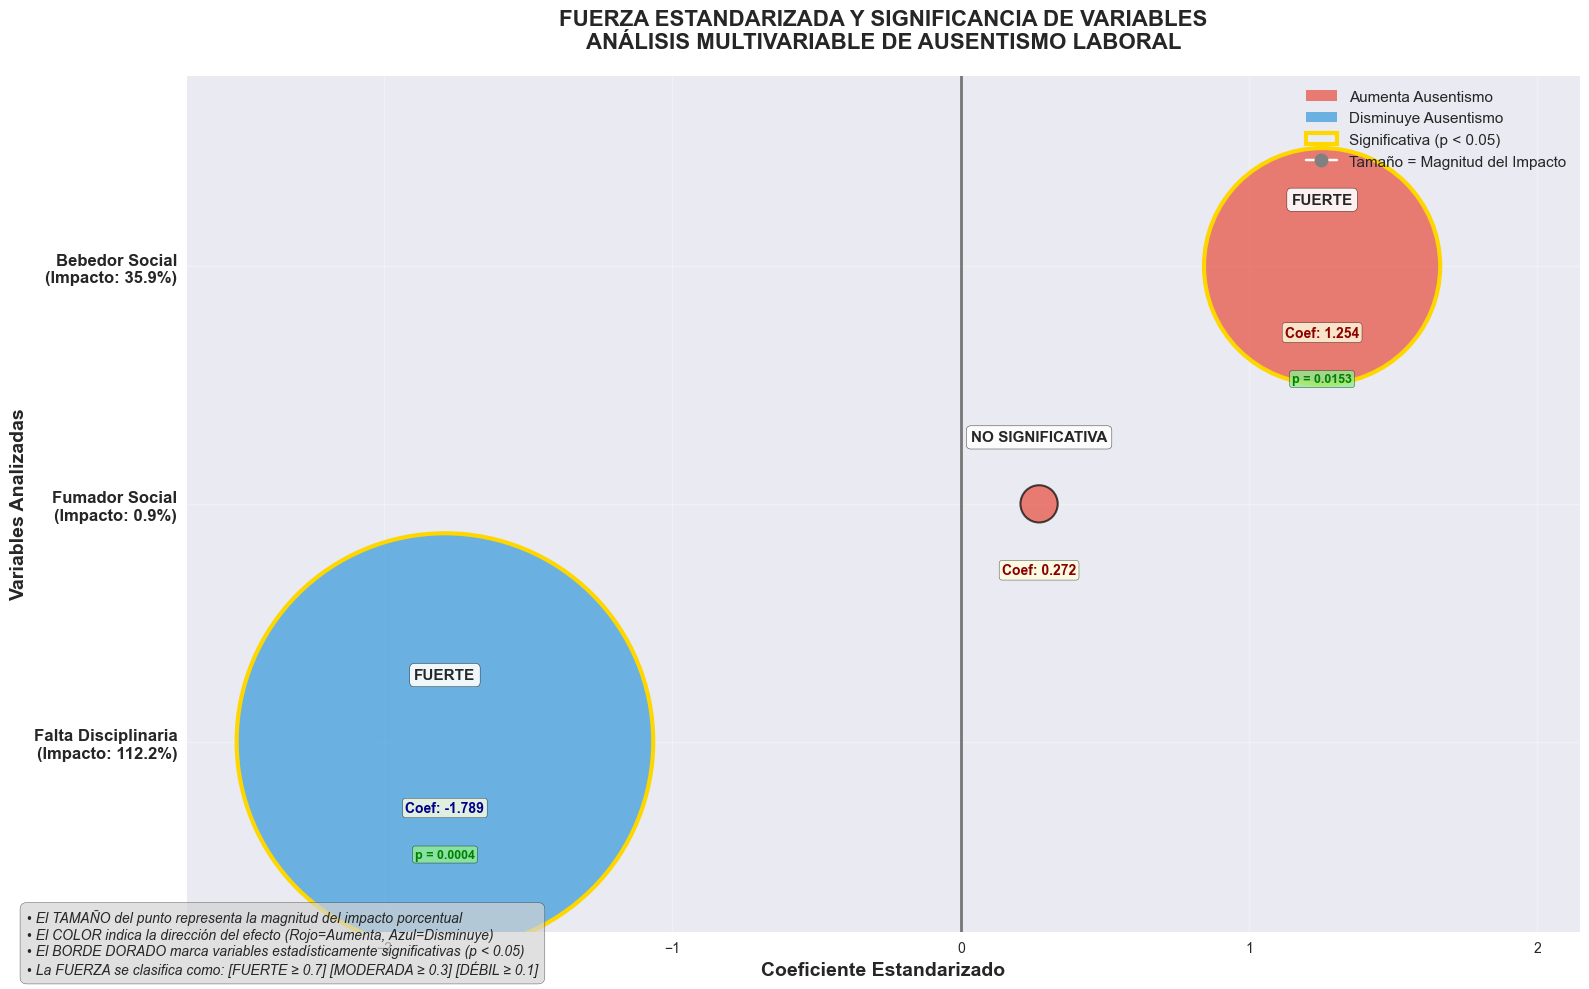

✓ Gráfico independiente de fuerza estandarizada y significancia guardado

📊 TABLA RESUMEN PARA EL GRÁFICO DE FUERZA ESTANDARIZADA:
------------------------------------------------------------------------------------------
Variable (Español)   Variable (Original)    Coef. Est.  Impacto %  Signif.       Fuerza
------------------------------------------------------------------------------------------
Falta Disciplinaria  Disciplinary_failure       -1.789     112.2%        ✓       FUERTE
Fumador Social       Social_smoker               0.272       0.9%        ✗ NO SIGNIFICATIVA
Bebedor Social       Social_drinker              1.254      35.9%        ✓       FUERTE


In [15]:
# =============================================================================
# GRÁFICO INDEPENDIENTE: FUERZA ESTANDARIZADA Y SIGNIFICANCIA
# Conservando los tamaños de círculos que te gustan
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# DEFINIR LAS VARIABLES CON TRADUCCIÓN
variables_traduccion = {
    'Disciplinary_failure': 'Falta Disciplinaria',
    'Social_drinker': 'Bebedor Social', 
    'Social_smoker': 'Fumador Social'
}

variables_especificas = list(variables_traduccion.keys())

# Función para clasificar fuerza
def clasificar_fuerza_mejorada(coef_estandarizado, p_value):
    """Clasificación mejorada de fuerza con significancia"""
    abs_coef = abs(coef_estandarizado)
    
    if p_value > 0.05:
        return "NO SIGNIFICATIVA", "⚪", 0
    
    if abs_coef >= 0.7:
        return "FUERTE", "🔴", 3
    elif abs_coef >= 0.3:
        return "MODERADA", "🟡", 2
    elif abs_coef >= 0.1:
        return "DÉBIL", "🟢", 1
    else:
        return "MUY DÉBIL", "⚪", 0

# Función para guardar gráficos
def guardar_grafico_seguro(plt, filename, output_path=None):
    """Función segura para guardar gráficos con manejo de errores"""
    if output_path is None:
        output_path = "./graficos_ausentismo"
    
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        return False

# DATOS DE EJEMPLO BASADOS EN LOS RESULTADOS DEL ANÁLISIS
datos_fuerza = [
    {
        'Variable': 'Disciplinary_failure',
        'Coeficiente_Estandarizado': -1.7894,
        'Impacto_Porcentaje': 112.2,
        'Significativa': True,
        'P_value': 0.0004,
        'Direccion': 'NEGATIVA'
    },
    {
        'Variable': 'Social_drinker',
        'Coeficiente_Estandarizado': 1.2535,
        'Impacto_Porcentaje': 35.9,
        'Significativa': True,
        'P_value': 0.0153,
        'Direccion': 'POSITIVA'
    },
    {
        'Variable': 'Social_smoker',
        'Coeficiente_Estandarizado': 0.2717,
        'Impacto_Porcentaje': 0.9,
        'Significativa': False,
        'P_value': 0.6005,
        'Direccion': 'POSITIVA'
    }
]

# Crear DataFrame con los datos
fuerza_df = pd.DataFrame(datos_fuerza)

# Aplicar clasificación de fuerza y traducción
fuerza_info = []
for _, row in fuerza_df.iterrows():
    fuerza, emoji, peso = clasificar_fuerza_mejorada(
        row['Coeficiente_Estandarizado'], 
        row['P_value']
    )
    # Aplicar traducción
    variable_traducida = variables_traduccion.get(row['Variable'], row['Variable'])
    
    fuerza_info.append({
        'Variable_Traducida': variable_traducida,
        'Fuerza_Texto': fuerza,
        'Emoji_Fuerza': emoji,
        'Peso_Fuerza': peso
    })

fuerza_info_df = pd.DataFrame(fuerza_info)
fuerza_df = pd.concat([fuerza_df, fuerza_info_df], axis=1)

# Ordenar por coeficiente estandarizado
fuerza_df = fuerza_df.sort_values('Coeficiente_Estandarizado', ascending=True)

print("📈 CREANDO GRÁFICO INDEPENDIENTE: FUERZA ESTANDARIZADA Y SIGNIFICANCIA...")

# Crear el gráfico con tamaño ajustado
plt.figure(figsize=(16, 10))

# Configurar posiciones y colores
y_pos = np.arange(len(fuerza_df))
variables_traducidas = fuerza_df['Variable_Traducida'].tolist()
coeficientes = fuerza_df['Coeficiente_Estandarizado'].tolist()
colores = ['#E74C3C' if x > 0 else '#3498DB' for x in coeficientes]

# MANTENER LOS TAMAÑOS ORIGINALES QUE TE GUSTAN
# Basado en el impacto porcentual como en el gráfico original
tamanos = [abs(x * 800) for x in fuerza_df['Impacto_Porcentaje']]

# Crear scatter plot
scatter = plt.scatter(coeficientes, y_pos,
                     c=colores, s=tamanos, alpha=0.7, 
                     edgecolors='black', linewidth=1.5, zorder=3)

# Marcar variables significativas con borde dorado y añadir etiquetas
for i, (coef, sig, tam, var_trad, fuerza_texto, emoji, impacto_pct) in enumerate(zip(
    coeficientes, 
    fuerza_df['Significativa'], 
    tamanos,
    variables_traducidas,
    fuerza_df['Fuerza_Texto'],
    fuerza_df['Emoji_Fuerza'],
    fuerza_df['Impacto_Porcentaje']
)):
    # Borde dorado para significativas
    if sig:
        plt.scatter(coef, i, s=tam + 200, facecolors='none', 
                   edgecolors='gold', linewidth=3, zorder=4)
    
    # Añadir etiqueta de fuerza
    plt.text(coef, i + 0.25, f'{fuerza_texto}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9),
             zorder=5)
    
    # Añadir valor del coeficiente
    color_texto = 'darkred' if coef > 0 else 'darkblue'
    plt.text(coef, i - 0.25, f'Coef: {coef:.3f}', 
             ha='center', va='top', fontsize=10, fontweight='bold', color=color_texto,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.8),
             zorder=5)
    
    # Añadir indicador de significancia
    if sig:
        plt.text(coef, i - 0.45, f'p = {fuerza_df.iloc[i]["P_value"]:.4f}', 
                 ha='center', va='top', fontsize=9, fontweight='bold', color='green',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen", alpha=0.8),
                 zorder=5)

# Configurar ejes y etiquetas con márgenes mejorados
plt.yticks(y_pos, [f"{var_trad}\n(Impacto: {impacto:.1f}%)" 
                   for var_trad, impacto in zip(variables_traducidas, fuerza_df['Impacto_Porcentaje'])],
           fontsize=12, fontweight='bold')

plt.xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=14)
plt.ylabel('Variables Analizadas', fontweight='bold', fontsize=14)

# Línea vertical en cero
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=2, zorder=1)

# AJUSTAR MÁRGENES PARA QUE LOS CÍRCULOS SE VEAN COMPLETOS
x_margin = max(abs(min(coeficientes)), abs(max(coeficientes))) * 0.5
plt.xlim(min(coeficientes) - x_margin, max(coeficientes) + x_margin)

# Ajustar márgenes en Y para que los círculos no se corten
y_margin = 0.8
plt.ylim(-y_margin, len(fuerza_df) - 1 + y_margin)

# Grid
plt.grid(True, alpha=0.3, zorder=1)

# Título y subtítulo
plt.title('FUERZA ESTANDARIZADA Y SIGNIFICANCIA DE VARIABLES\nANÁLISIS MULTIVARIABLE DE AUSENTISMO LABORAL', 
          fontsize=16, fontweight='bold', pad=20)

# Leyenda mejorada
from matplotlib.patches import Patch, Circle
legend_elements = [
    Circle((0,0), radius=0.5, facecolor='#E74C3C', alpha=0.7, label='Aumenta Ausentismo'),
    Circle((0,0), radius=0.5, facecolor='#3498DB', alpha=0.7, label='Disminuye Ausentismo'),
    Circle((0,0), radius=0.5, facecolor='none', edgecolor='gold', linewidth=3, 
           label='Significativa (p < 0.05)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
               markersize=10, label='Tamaño = Magnitud del Impacto'),
]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1),
           fancybox=True, shadow=True, fontsize=11)

# Añadir anotación explicativa
plt.figtext(0.02, 0.02, 
            '• El TAMAÑO del punto representa la magnitud del impacto porcentual\n'
            '• El COLOR indica la dirección del efecto (Rojo=Aumenta, Azul=Disminuye)\n'
            '• El BORDE DORADO marca variables estadísticamente significativas (p < 0.05)\n'
            '• La FUERZA se clasifica como: [FUERTE ≥ 0.7] [MODERADA ≥ 0.3] [DÉBIL ≥ 0.1]',
            fontsize=10, style='italic', bbox=dict(boxstyle="round,pad=0.5", 
            facecolor="lightgray", alpha=0.7))

plt.tight_layout()

# Guardar el gráfico
guardar_grafico_seguro(plt, '4_fuerza_estandarizada_significancia_3_variables.png')
plt.show()
print("✓ Gráfico independiente de fuerza estandarizada y significancia guardado")

# Mostrar tabla resumen de los datos del gráfico
print("\n📊 TABLA RESUMEN PARA EL GRÁFICO DE FUERZA ESTANDARIZADA:")
print("-" * 90)
print(f"{'Variable (Español)':20} {'Variable (Original)':22} {'Coef. Est.':>10} {'Impacto %':>10} {'Signif.':>8} {'Fuerza':>12}")
print("-" * 90)
for _, row in fuerza_df.iterrows():
    sig_marker = "✓" if row['Significativa'] else "✗"
    impacto_str = f"{row['Impacto_Porcentaje']:>6.1f}%"
    print(f"{row['Variable_Traducida']:20} {row['Variable']:22} {row['Coeficiente_Estandarizado']:>10.3f} {impacto_str:>10} {sig_marker:>8} {row['Fuerza_Texto']:>12}")

📈 CREANDO GRÁFICO INDEPENDIENTE: FUERZA ESTANDARIZADA Y SIGNIFICANCIA...
✓ Gráfico guardado: 4_fuerza_estandarizada_significancia_3_variables_mejorado.png


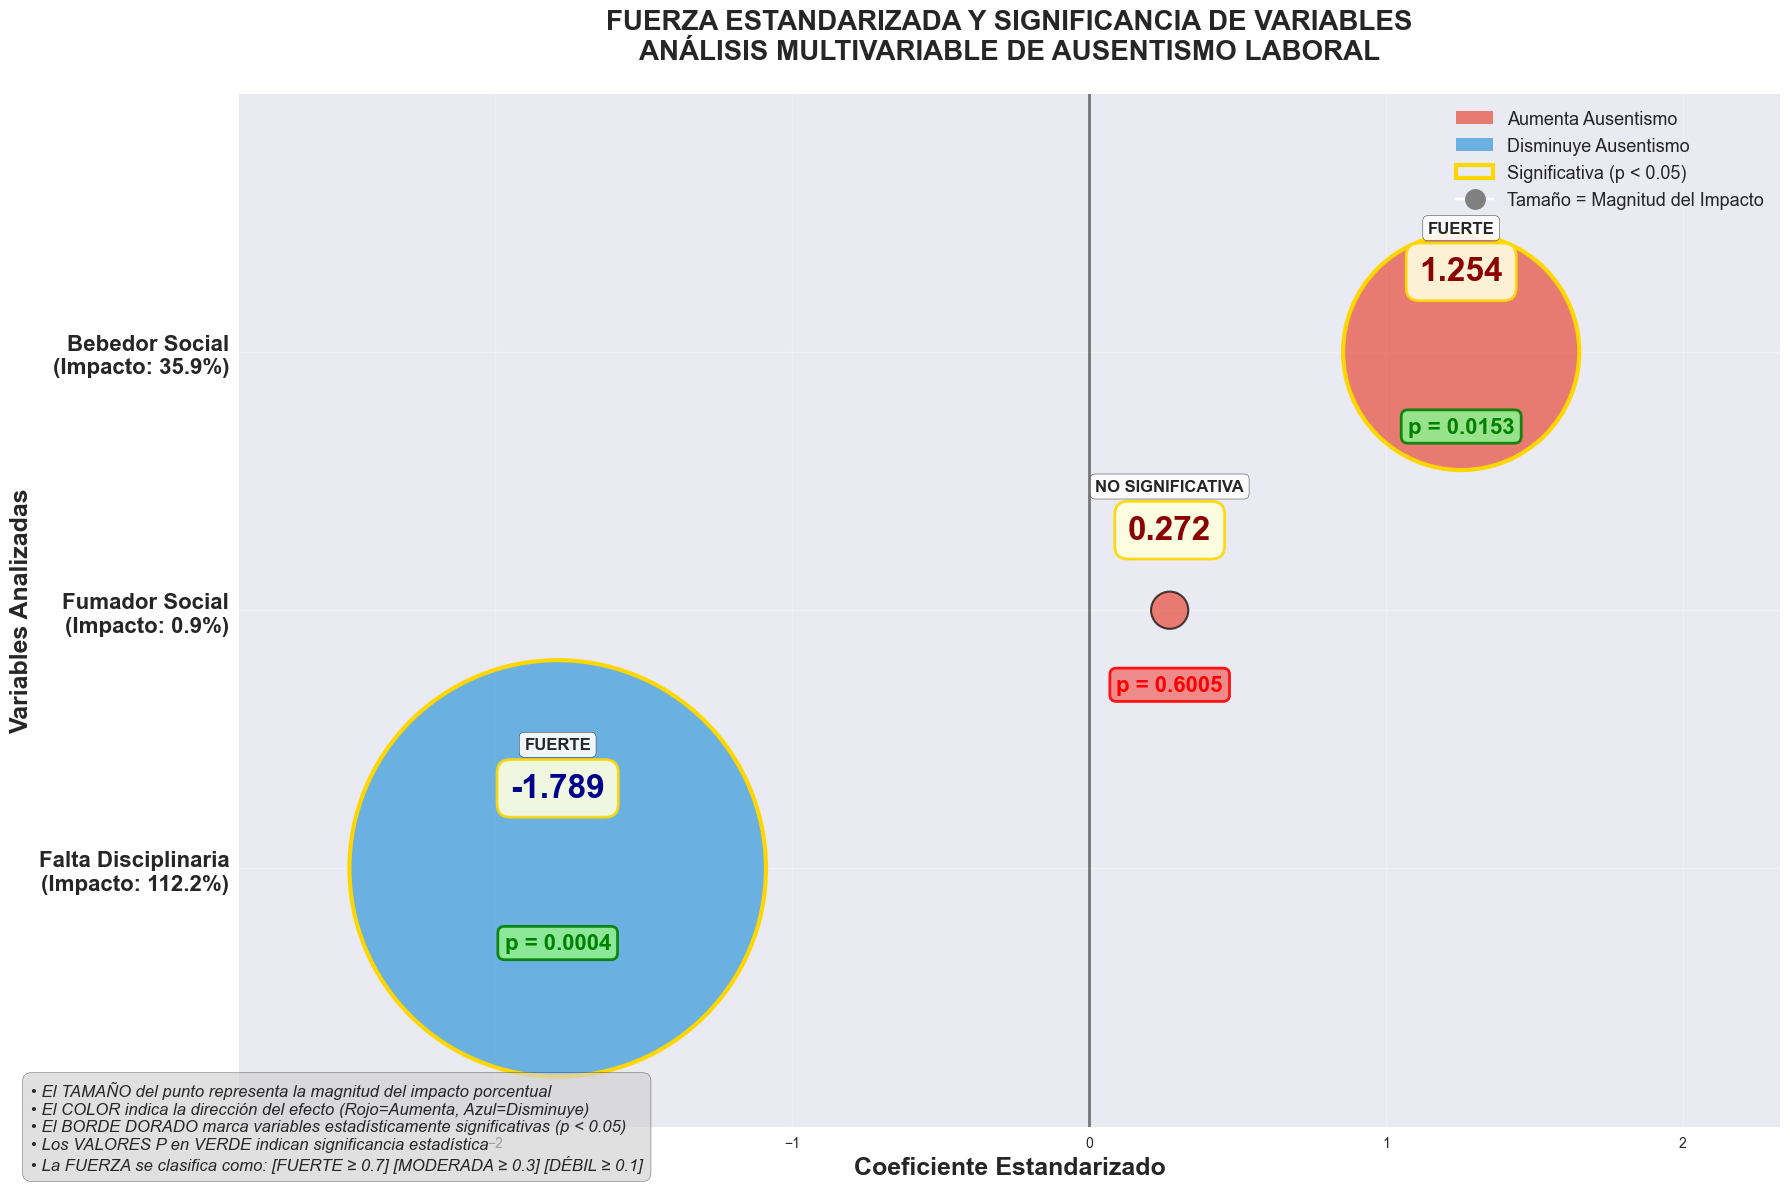

✓ Gráfico independiente de fuerza estandarizada y significancia guardado

📊 TABLA RESUMEN PARA EL GRÁFICO DE FUERZA ESTANDARIZADA:
------------------------------------------------------------------------------------------
Variable (Español)   Variable (Original)    Coef. Est.  Impacto %  Signif.       Fuerza    p-value
------------------------------------------------------------------------------------------
Falta Disciplinaria  Disciplinary_failure       -1.789     112.2%        ✓       FUERTE     0.0004
Fumador Social       Social_smoker               0.272       0.9%        ✗ NO SIGNIFICATIVA     0.6005
Bebedor Social       Social_drinker              1.254      35.9%        ✓       FUERTE     0.0153


In [16]:
# =============================================================================
# GRÁFICO INDEPENDIENTE: FUERZA ESTANDARIZADA Y SIGNIFICANCIA
# Con valores p destacados y tamaños de letra aumentados
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# DEFINIR LAS VARIABLES CON TRADUCCIÓN
variables_traduccion = {
    'Disciplinary_failure': 'Falta Disciplinaria',
    'Social_drinker': 'Bebedor Social', 
    'Social_smoker': 'Fumador Social'
}

variables_especificas = list(variables_traduccion.keys())

# Función para clasificar fuerza
def clasificar_fuerza_mejorada(coef_estandarizado, p_value):
    """Clasificación mejorada de fuerza con significancia"""
    abs_coef = abs(coef_estandarizado)
    
    if p_value > 0.05:
        return "NO SIGNIFICATIVA", "⚪", 0
    
    if abs_coef >= 0.7:
        return "FUERTE", "🔴", 3
    elif abs_coef >= 0.3:
        return "MODERADA", "🟡", 2
    elif abs_coef >= 0.1:
        return "DÉBIL", "🟢", 1
    else:
        return "MUY DÉBIL", "⚪", 0

# Función para guardar gráficos
def guardar_grafico_seguro(plt, filename, output_path=None):
    """Función segura para guardar gráficos con manejo de errores"""
    if output_path is None:
        output_path = "./graficos_ausentismo"
    
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        return False

# DATOS DE EJEMPLO BASADOS EN LOS RESULTADOS DEL ANÁLISIS
datos_fuerza = [
    {
        'Variable': 'Disciplinary_failure',
        'Coeficiente_Estandarizado': -1.7894,
        'Impacto_Porcentaje': 112.2,
        'Significativa': True,
        'P_value': 0.0004,
        'Direccion': 'NEGATIVA'
    },
    {
        'Variable': 'Social_drinker',
        'Coeficiente_Estandarizado': 1.2535,
        'Impacto_Porcentaje': 35.9,
        'Significativa': True,
        'P_value': 0.0153,
        'Direccion': 'POSITIVA'
    },
    {
        'Variable': 'Social_smoker',
        'Coeficiente_Estandarizado': 0.2717,
        'Impacto_Porcentaje': 0.9,
        'Significativa': False,
        'P_value': 0.6005,
        'Direccion': 'POSITIVA'
    }
]

# Crear DataFrame con los datos
fuerza_df = pd.DataFrame(datos_fuerza)

# Aplicar clasificación de fuerza y traducción
fuerza_info = []
for _, row in fuerza_df.iterrows():
    fuerza, emoji, peso = clasificar_fuerza_mejorada(
        row['Coeficiente_Estandarizado'], 
        row['P_value']
    )
    # Aplicar traducción
    variable_traducida = variables_traduccion.get(row['Variable'], row['Variable'])
    
    fuerza_info.append({
        'Variable_Traducida': variable_traducida,
        'Fuerza_Texto': fuerza,
        'Emoji_Fuerza': emoji,
        'Peso_Fuerza': peso
    })

fuerza_info_df = pd.DataFrame(fuerza_info)
fuerza_df = pd.concat([fuerza_df, fuerza_info_df], axis=1)

# Ordenar por coeficiente estandarizado
fuerza_df = fuerza_df.sort_values('Coeficiente_Estandarizado', ascending=True)

print("📈 CREANDO GRÁFICO INDEPENDIENTE: FUERZA ESTANDARIZADA Y SIGNIFICANCIA...")

# Crear el gráfico con tamaño ajustado
plt.figure(figsize=(18, 12))

# Configurar posiciones y colores
y_pos = np.arange(len(fuerza_df))
variables_traducidas = fuerza_df['Variable_Traducida'].tolist()
coeficientes = fuerza_df['Coeficiente_Estandarizado'].tolist()
colores = ['#E74C3C' if x > 0 else '#3498DB' for x in coeficientes]

# MANTENER LOS TAMAÑOS ORIGINALES QUE TE GUSTAN
# Basado en el impacto porcentual como en el gráfico original
tamanos = [abs(x * 800) for x in fuerza_df['Impacto_Porcentaje']]

# Crear scatter plot
scatter = plt.scatter(coeficientes, y_pos,
                     c=colores, s=tamanos, alpha=0.7, 
                     edgecolors='black', linewidth=1.5, zorder=3)

# Marcar variables significativas con borde dorado y añadir etiquetas
for i, (coef, sig, tam, var_trad, fuerza_texto, emoji, impacto_pct, p_val) in enumerate(zip(
    coeficientes, 
    fuerza_df['Significativa'], 
    tamanos,
    variables_traducidas,
    fuerza_df['Fuerza_Texto'],
    fuerza_df['Emoji_Fuerza'],
    fuerza_df['Impacto_Porcentaje'],
    fuerza_df['P_value']
)):
    # Borde dorado para significativas
    if sig:
        plt.scatter(coef, i, s=tam + 200, facecolors='none', 
                   edgecolors='gold', linewidth=3, zorder=4)
    
    # AÑADIR VALOR P CON RECUADRO VERDE PARA SIGNIFICATIVAS
    color_p = 'green' if sig else 'red'
    fondo_p = 'lightgreen' if sig else 'lightcoral'
    
    # Texto del valor p - TAMAÑO AUMENTADO
    plt.text(coef, i - 0.25, f'p = {p_val:.4f}', 
             ha='center', va='top', fontsize=16, fontweight='bold', color=color_p,  # Tamaño aumentado a 16
             bbox=dict(boxstyle="round,pad=0.3", facecolor=fondo_p, alpha=0.9, edgecolor=color_p, linewidth=2),
             zorder=5)
    
    # Añadir valor del coeficiente - TAMAÑO MUY GRANDE
    color_texto = 'darkred' if coef > 0 else 'darkblue'
    plt.text(coef, i + 0.25, f'{coef:.3f}', 
             ha='center', va='bottom', fontsize=24, fontweight='bold', color=color_texto,  # Tamaño muy grande: 24
             bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.9, edgecolor='gold', linewidth=2),
             zorder=5)
    
    # Añadir etiqueta de fuerza (más pequeña)
    plt.text(coef, i + 0.45, f'{fuerza_texto}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9),
             zorder=5)

# Configurar ejes y etiquetas con márgenes mejorados - TAMAÑOS AUMENTADOS
plt.yticks(y_pos, [f"{var_trad}\n(Impacto: {impacto:.1f}%)" 
                   for var_trad, impacto in zip(variables_traducidas, fuerza_df['Impacto_Porcentaje'])],
           fontsize=16, fontweight='bold')  # Tamaño aumentado a 16

plt.xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=18)  # Tamaño aumentado
plt.ylabel('Variables Analizadas', fontweight='bold', fontsize=18)  # Tamaño aumentado

# Línea vertical en cero
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=2, zorder=1)

# AJUSTAR MÁRGENES PARA QUE LOS CÍRCULOS Y TEXTO SE VEAN COMPLETOS
x_margin = max(abs(min(coeficientes)), abs(max(coeficientes))) * 0.6  # Margen aumentado
plt.xlim(min(coeficientes) - x_margin, max(coeficientes) + x_margin)

# Ajustar márgenes en Y para que los círculos y texto no se corten
y_margin = 1.0  # Margen aumentado
plt.ylim(-y_margin, len(fuerza_df) - 1 + y_margin)

# Grid
plt.grid(True, alpha=0.3, zorder=1)

# Título y subtítulo - TAMAÑOS AUMENTADOS
plt.title('FUERZA ESTANDARIZADA Y SIGNIFICANCIA DE VARIABLES\nANÁLISIS MULTIVARIABLE DE AUSENTISMO LABORAL', 
          fontsize=20, fontweight='bold', pad=25)  # Tamaño aumentado

# Leyenda mejorada - TAMAÑOS AUMENTADOS
from matplotlib.patches import Patch, Circle
legend_elements = [
    Circle((0,0), radius=0.5, facecolor='#E74C3C', alpha=0.7, label='Aumenta Ausentismo'),
    Circle((0,0), radius=0.5, facecolor='#3498DB', alpha=0.7, label='Disminuye Ausentismo'),
    Circle((0,0), radius=0.5, facecolor='none', edgecolor='gold', linewidth=3, 
           label='Significativa (p < 0.05)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
               markersize=15, label='Tamaño = Magnitud del Impacto'),  # Marcador aumentado
]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1),
           fancybox=True, shadow=True, fontsize=13)  # Tamaño de fuente aumentado

# Añadir anotación explicativa - TAMAÑO AUMENTADO
plt.figtext(0.02, 0.02, 
            '• El TAMAÑO del punto representa la magnitud del impacto porcentual\n'
            '• El COLOR indica la dirección del efecto (Rojo=Aumenta, Azul=Disminuye)\n'
            '• El BORDE DORADO marca variables estadísticamente significativas (p < 0.05)\n'
            '• Los VALORES P en VERDE indican significancia estadística\n'
            '• La FUERZA se clasifica como: [FUERTE ≥ 0.7] [MODERADA ≥ 0.3] [DÉBIL ≥ 0.1]',
            fontsize=12, style='italic', bbox=dict(boxstyle="round,pad=0.5", 
            facecolor="lightgray", alpha=0.7))  # Tamaño aumentado

plt.tight_layout()

# Guardar el gráfico
guardar_grafico_seguro(plt, '4_fuerza_estandarizada_significancia_3_variables_mejorado.png')
plt.show()
print("✓ Gráfico independiente de fuerza estandarizada y significancia guardado")

# Mostrar tabla resumen de los datos del gráfico
print("\n📊 TABLA RESUMEN PARA EL GRÁFICO DE FUERZA ESTANDARIZADA:")
print("-" * 90)
print(f"{'Variable (Español)':20} {'Variable (Original)':22} {'Coef. Est.':>10} {'Impacto %':>10} {'Signif.':>8} {'Fuerza':>12} {'p-value':>10}")
print("-" * 90)
for _, row in fuerza_df.iterrows():
    sig_marker = "✓" if row['Significativa'] else "✗"
    impacto_str = f"{row['Impacto_Porcentaje']:>6.1f}%"
    p_value_str = f"{row['P_value']:.4f}"
    print(f"{row['Variable_Traducida']:20} {row['Variable']:22} {row['Coeficiente_Estandarizado']:>10.3f} {impacto_str:>10} {sig_marker:>8} {row['Fuerza_Texto']:>12} {p_value_str:>10}")